# DynaSD Validation Analysis

In [263]:
import numpy as np
import pandas as pd
import scipy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator

import sys
import os
from os.path import join as ospj
from scipy.stats import spearmanr, pearsonr
import statsmodels.api as sm
import statsmodels.formula.api as smf
from kneed import KneeLocator
from tqdm import tqdm
import nibabel as nib
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, f1_score
from sklearn.linear_model import LogisticRegression
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from DSOSD.utils import load_config, cohens_d, clean_labels, remove_scalp_electrodes

In [ ]:
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['lines.linewidth'] = 2

plt.rcParams['xtick.major.size'] = 5  # Change to your desired major tick size
plt.rcParams['ytick.major.size'] = 5  # Change to your desired major tick size
plt.rcParams['xtick.minor.size'] = 3   # Change to your desired minor tick size
plt.rcParams['ytick.minor.size'] = 3   # Change to your desired minor tick size

plt.rcParams['xtick.major.width'] = 2  # Change to your desired major tick width
plt.rcParams['ytick.major.width'] = 2  # Change to your desired major tick width
plt.rcParams['xtick.minor.width'] = 1  # Change to your desired minor tick width
plt.rcParams['ytick.minor.width'] = 1  # Change to your desired minor tick width
plt.rcParams['font.family'] = 'Verdana'

pal = sns.color_palette('Set2')[:2][::-1] + ['grey']

In [265]:
def plot_sig_nsig(sig,nsig,bins=np.linspace(-1,1,20),vbox_int=10):
    # Count data in each bin
    bin_width = bins[1] - bins[0]

    hist_sig, _ = np.histogram(sig, bins=bins)
    hist_not_sig, _ = np.histogram(nsig, bins=bins)

    # Create the blocks
    fig, ax = plt.subplots()

    # Plot each block for not significant
    for i, count in enumerate(hist_not_sig):
        ax.bar(bins[i], count, width=bin_width, color=sns.color_palette('rocket_r')[4], edgecolor='none', label='not significant' if i == 0 else "")

    # Plot each block for significant
    for i, count in enumerate(hist_sig):
        ax.bar(bins[i], count, width=bin_width, color=sns.color_palette('rocket_r')[2], edgecolor='none', bottom=hist_not_sig[i],
            label='significant' if i == 0 else "")
        
    for i in range(0,max(hist_sig+hist_not_sig),vbox_int):
        plt.axhline(i,color='white')
    for i in bins:
        plt.axvline(i + bin_width/2,color='white')
    # Customize plot
    ax.legend()
    plt.tight_layout()
    return fig,ax
    

In [266]:
def get_nparam_stats(data,group,x1,x2,val):
    d1 = data[data[group] == x1][val].to_numpy()
    d2 = data[data[group] == x2][val].to_numpy()
    u,p = sc.stats.mannwhitneyu(d1,d2)
    auc = u/(len(d1)*len(d2))
    return p,u,auc

In [267]:
usr,passpath,datapath,prodatapath,metapath,figpath = load_config(ospj('/Users/wojemann/Documents/CNT/DSOSD/','config.json'))

In [268]:
prodatapath

'/Users/wojemann/Documents/CNT/DSOSD/PROCESSED_DATA'

In [269]:
metapath

'/Users/wojemann/Documents/CNT/DSOSD/METADATA'

In [270]:
metadata_df = pd.read_csv(ospj(metapath,'metadata_v3.csv'))
metadata_df['patient'] = 'HUP' + metadata_df.patient.astype(int).astype(str).apply(lambda x: x.zfill(3))
metadata_df.drop([col for col in metadata_df.columns if 'Unnamed' in col],axis=1,inplace=True)
metadata_df['stim induced'] = metadata_df['stim induced'].fillna(0)
metadata_df['notes'] = metadata_df['notes'].fillna('')
metadata_df = metadata_df[(metadata_df['stim induced'] < 1)]

metadata_df['onset'] = metadata_df['onset'].astype(float)

metadata_df['outcome'] = metadata_df.seizure_Engel24m.astype(float)
# outcome_mask = metadata_df.outcome.isna() & (metadata_df.seizure_Engel12m.astype(float) >= 2)
# metadata_df.loc[outcome_mask,'outcome'] = metadata_df[["seizure_Engel12m"]].astype(float)
# metadata_df['outcome'] = metadata_df['outcome'].fillna(metadata_df.seizure_Engel12m.astype(float))

## testing outcome extremes
# middle_mask = (metadata_df.outcome >1.2) & (metadata_df.outcome < 2) & (metadata_df.outcome_val==False)
# middle_mask = metadata_df.outcome_val == False
# metadata_df.loc[middle_mask,'outcome'] = np.nan
##

metadata_df.loc[~metadata_df.outcome.isna(),'outcome'] = (metadata_df.loc[~metadata_df.outcome.isna(),'outcome'] <= 1.2).astype(float)
metadata_df['ieeg_isFocal'] = metadata_df.ieeg_isFocal == 1

def alt_focality(row):
    if row.SOZ_region == 'diffuse':
        alt_focal = 'diffuse'
    else:
        alt_focal = 'focal'
    return alt_focal

metadata_df['alt_focal'] = metadata_df.apply(alt_focality,axis=1)

def all_focality(row):
    if row.SOZ_region == 'diffuse':
        alt_focal = 'diffuse'
    elif row.ieeg_isFocal == 0:
        alt_focal = 'multifocal'
    else:
        alt_focal = 'unifocal'
    return alt_focal

metadata_df['all_focal'] = metadata_df.apply(all_focality,axis=1)


In [155]:
metadata_df = metadata_df[~metadata_df.patient.isin(['HUP225','HUP224'])]

In [156]:
metadata_df.columns

Index(['record_id', 'patient', 'seizure_Engel12m', 'seizure_Engel24m',
       'SOZ_Electrode', 'SOZ_Localization', 'SOZ_region', 'SOZ_lateralization',
       'fiveSenseScore', 'ieeg_isFocal', 'BER_exists',
       'interictal_abnormalities_exist', 'BER_and_interictal', 'IEEGID',
       'fname', 'onset', 'offset', 'source', 'notes', 'Semiology',
       'stim induced', 'HUP_Patient', 'outcome_val', 'outcome', 'alt_focal',
       'all_focal'],
      dtype='object')

In [157]:
# metadata_df = metadata_df[metadata_df.notes.apply(lambda x: 'nina' not in x.lower())]
# metadata_df = metadata_df[metadata_df.source.apply(lambda x: 'nina' not in x.lower())]

In [158]:
pt_metadata_df = metadata_df.groupby('patient')[['record_id','outcome','SOZ_region','SOZ_lateralization','fiveSenseScore','ieeg_isFocal','Semiology','alt_focal','all_focal']].apply(lambda x: x.iloc[0,:])

In [271]:
thresh_str = 'automedian'
similarity_df = pd.read_pickle(ospj(prodatapath,f"patient_similarity_analysis_{thresh_str}_sec-10.pkl"))
summary_df = pd.read_pickle(ospj(prodatapath,f"seizure_spread_summary_{thresh_str}_sec-10.pkl"))

In [272]:
summary_df.columns

Index(['patient', 'onset', 'onset_channels', 'spread_channels',
       'channel_spread_rank', 'channel_spread_time', 'fraction_seizing',
       'abs_seizing', 'all_channels', 'onset_ndd_cum', 'onset_ndd_ind'],
      dtype='object')

In [273]:
summary_df_wmeta = summary_df.merge(metadata_df,how='inner',on=['patient','onset'])
summary_df_wmeta.dropna(subset= ['ieeg_isFocal'],axis=0,how='any')
# summary_df_wmeta.to_csv(ospj(prodatapath,'seizure_level_annotations_wmeta.csv'))
# summary_df_wmeta.to_pickle(ospj(prodatapath,'seizure_level_annotations_wmeta.pkl'))
similarity_df_wmeta = similarity_df.merge(pt_metadata_df,how='inner',on='patient')
similarity_df_wmeta = similarity_df_wmeta.dropna(subset= ['ieeg_isFocal','avg_dice_similarity','avg_spearman'],axis=0,how='any')

In [274]:
def get_total_chs(group):
    all_chs = set()
    for _,row in group.iterrows():
        all_chs.update(row.all_channels)
    return len(all_chs)
total_chs = summary_df.groupby('patient').apply(get_total_chs).reset_index()
total_chs.columns = ['patient','total_chs']

/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_8208/2819080382.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  total_chs = summary_df.groupby('patient').apply(get_total_chs).reset_index()


In [275]:
similarity_df_wmeta = similarity_df_wmeta.merge(total_chs,on='patient')

In [276]:
print(len(similarity_df_wmeta.patient.unique()),len(summary_df_wmeta))

114 1329


In [277]:
np.sort(summary_df_wmeta[summary_df_wmeta.outcome.isna()].patient.unique())

array(['HUP068', 'HUP081', 'HUP084', 'HUP096', 'HUP100', 'HUP101',
       'HUP108', 'HUP112', 'HUP114', 'HUP119', 'HUP121', 'HUP127',
       'HUP128', 'HUP129', 'HUP131', 'HUP136', 'HUP137', 'HUP143',
       'HUP147', 'HUP149', 'HUP151', 'HUP152', 'HUP153', 'HUP154',
       'HUP155', 'HUP156', 'HUP159', 'HUP167', 'HUP168', 'HUP169',
       'HUP174', 'HUP175', 'HUP178', 'HUP182', 'HUP186', 'HUP190',
       'HUP192', 'HUP193', 'HUP195', 'HUP196', 'HUP197', 'HUP199',
       'HUP202', 'HUP203', 'HUP205', 'HUP209', 'HUP210', 'HUP211',
       'HUP213', 'HUP214', 'HUP224', 'HUP225'], dtype=object)

In [278]:
ndd_df = pd.read_pickle(ospj(prodatapath,'pair_DNN_DTW_analysis.pkl'))
ndd_df[['temporal_distance','dtw_distance']] = ndd_df[['temporal_distance','dtw_distance']].astype(float)
# ndd_df['dtw_distance'] = ndd_df['dtw_distance'].apply(lambda x: np.log(x+1e-50))
ndd_df_wmeta = ndd_df.merge(pt_metadata_df,how='inner',on=['patient'])
ndd_df_wmeta.dropna(subset=['ieeg_isFocal','dtw_distance'],axis=0,inplace=True)

In [279]:
summary_df_wmeta[(summary_df_wmeta.SOZ_region == 'temporal') & (summary_df_wmeta.all_focal == 'unifocal')].outcome

102     1.0
103     1.0
104     1.0
254     NaN
255     NaN
       ... 
1320    1.0
1321    1.0
1322    1.0
1323    1.0
1324    1.0
Name: outcome, Length: 76, dtype: float64

## NDD Similarity

In [280]:
ndd_df_wmeta.head()

,patient,onset_1,onset_2,temporal_distance,dtw_distance,record_id,outcome,SOZ_region,SOZ_lateralization,fiveSenseScore,ieeg_isFocal,Semiology,alt_focal,all_focal
0,HUP065,228925.0,223606.0,5319.00,2015.994208,55,1.0,temporal,right,0.186988,True,FBTCS,focal,unifocal
1,HUP065,228925.0,249851.0,20926.00,2705.089305,55,1.0,temporal,right,0.186988,True,FBTCS,focal,unifocal
2,HUP065,223606.0,249851.0,26245.00,2546.835160,55,1.0,temporal,right,0.186988,True,FBTCS,focal,unifocal
3,HUP068,933639.0,911307.0,22332.00,5127.733551,58,NaN,temporal,right,0.186988,True,FBTCS,focal,unifocal
4,HUP068,933639.0,819104.46,114534.54,5656.763140,58,NaN,temporal,right,0.186988,True,FBTCS,focal,unifocal


<Axes: xlabel='temporal_distance', ylabel='dtw_distance'>

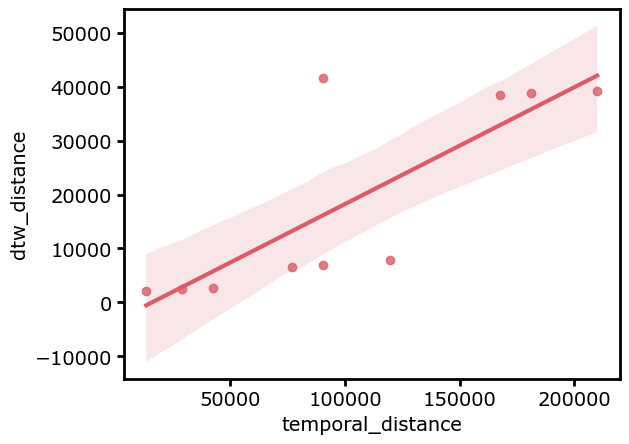

In [226]:
sns.regplot(ndd_df_wmeta[ndd_df_wmeta.patient=='HUP138'],x='temporal_distance',y='dtw_distance',color=sns.color_palette('plasma')[3])

In [24]:
def corr_func(group):
    dtw_r,dtw_p = spearmanr(group.temporal_distance,group.dtw_distance,alternative='greater')
    return pd.Series([dtw_p,dtw_r],index=['dtw_p','dtw_r'])
all_pt_ndd_ps = ndd_df_wmeta.groupby('patient').apply(corr_func) + 1e-50
all_pt_ndd_ps = all_pt_ndd_ps.dropna(subset=['dtw_p','dtw_r'],axis=0)

/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_61009/3833181625.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  all_pt_ndd_ps = ndd_df_wmeta.groupby('patient').apply(corr_func) + 1e-50


Text(37.888888888888886, 0.5, 'Patients')

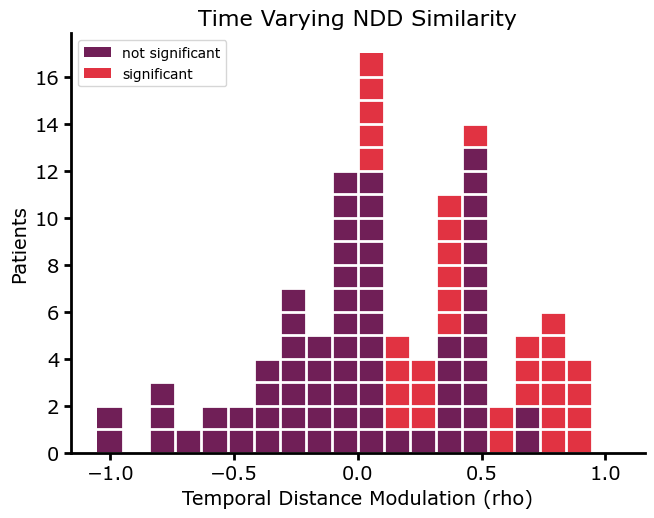

In [25]:
plot_sig_nsig(all_pt_ndd_ps.dtw_r[all_pt_ndd_ps.dtw_p < 0.05],all_pt_ndd_ps.dtw_r[all_pt_ndd_ps.dtw_p >= 0.05],vbox_int=1)
sns.despine()
plt.title('Time Varying NDD Similarity')
plt.xlabel('Temporal Distance Modulation (rho)')
plt.ylabel('Patients')

In [26]:
print(sc.stats.wilcoxon(all_pt_ndd_ps.dtw_r))
print(sc.stats.combine_pvalues(all_pt_ndd_ps.dtw_p))

WilcoxonResult(statistic=1491.5, pvalue=2.268129622852916e-05)
SignificanceResult(statistic=2259.4286704339984, pvalue=0.0)


### Patient level NDD analyses

In [27]:
pt_ndd_df = ndd_df.groupby('patient')[['temporal_distance','dtw_distance']].mean()
pt_ndd_df_wmeta = pt_ndd_df.merge(pt_metadata_df,on='patient',how='inner')
pt_ndd_df_wmeta

,temporal_distance,dtw_distance,record_id,outcome,SOZ_region,SOZ_lateralization,fiveSenseScore,ieeg_isFocal,Semiology,alt_focal,all_focal
patient,,,,,,,,,,,
HUP065,17496.666667,2422.639557,55,1.0,temporal,right,0.186988,True,FBTCS,focal,unifocal
HUP068,79057.944000,7839.817151,58,NaN,temporal,right,0.186988,True,FBTCS,focal,unifocal
HUP070,136353.928571,1338.279794,60,1.0,other cortex,left,0.316155,True,FAS,focal,unifocal
HUP073,49165.552000,1149.378892,63,0.0,other cortex,right,0.204257,True,FBTCS,focal,unifocal
HUP074,150078.200000,8295.086738,64,1.0,temporal,left,0.036428,True,FBTCS,focal,unifocal
...,...,...,...,...,...,...,...,...,...,...,...
HUP217,84586.566667,6988.446475,679,1.0,mesial temporal,right,0.928262,True,NaN,focal,unifocal
HUP218,118481.735785,4516.540451,677,0.0,mesial temporal,right,0.204257,True,NaN,focal,unifocal
HUP219,20935.096000,5137.281576,695,0.0,mesial temporal,right,0.292350,True,NaN,focal,unifocal


<Axes: ylabel='dtw_distance'>

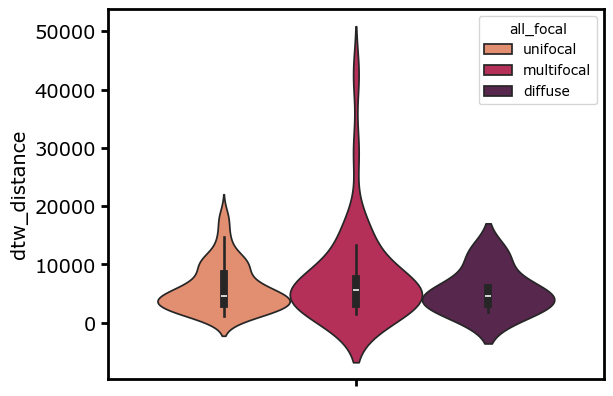

In [28]:
sns.violinplot(pt_ndd_df_wmeta,y='dtw_distance',hue='all_focal',palette='rocket_r')

In [29]:
sc.stats.mannwhitneyu(pt_ndd_df_wmeta[pt_ndd_df_wmeta.all_focal == 'unifocal'].dtw_distance,
                      pt_ndd_df_wmeta[pt_ndd_df_wmeta.all_focal == 'multifocal'].dtw_distance)

MannwhitneyuResult(statistic=1226.0, pvalue=0.35632344039650077)

In [30]:
cohens_d(pt_ndd_df_wmeta[pt_ndd_df_wmeta.all_focal == 'unifocal'].dtw_distance,
                      pt_ndd_df_wmeta[pt_ndd_df_wmeta.all_focal == 'multifocal'].dtw_distance)

-0.36353445717791244

## $NDD_{\tau}$

### Channel baseline

MannwhitneyuResult(statistic=979.0, pvalue=0.004296176591945774)

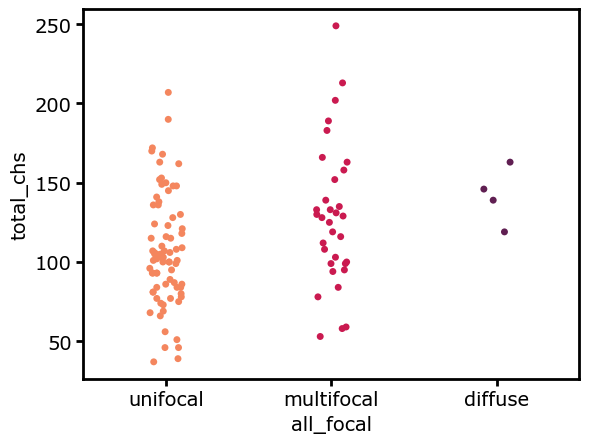

In [227]:
sns.stripplot(similarity_df_wmeta,x='all_focal',hue='all_focal',y='total_chs',palette='rocket_r')
# sns.violinplot(similarity_df_wmeta,x='ieeg_isFocal',hue='ieeg_isFocal',y='total_chs',palette='rocket',fill=False,inner='quart',width=.5)
sc.stats.mannwhitneyu(similarity_df_wmeta[similarity_df_wmeta.ieeg_isFocal == 1].total_chs,
                 
                     similarity_df_wmeta[similarity_df_wmeta.ieeg_isFocal == 0].total_chs)

### Semiology

In [228]:
# Define the time variable
time_points = np.arange(0, 60.5, 0.5)

# Expand DataFrame
expanded_data = []
for _, row in summary_df_wmeta.iterrows():
    for t, value in zip(time_points, row["fraction_seizing"]):
        expanded_data.append({
            "time": t,
            "percent_seizing": value*100,
            "patient": row["patient"],
            "isFocal": row["ieeg_isFocal"],
            "outcome": row["outcome"],
            "Semiology": row["Semiology"],
            "onset": row['onset'],
            "Focality": row['alt_focal'],
            "laterality": row['SOZ_lateralization'] == 'bilateral'
        })

# Create the expanded DataFrame
long_df = pd.DataFrame(expanded_data)


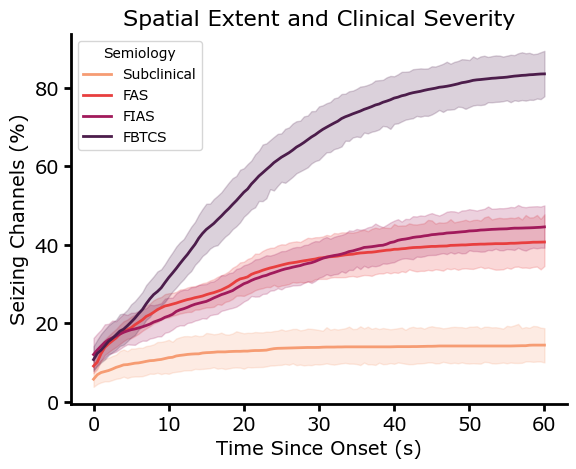

In [229]:
# Example grouped line plot
sns.lineplot(
    data=long_df,
    x="time",
    y="percent_seizing",
    hue="Semiology",
    legend=True,
    palette = 'rocket_r',
    hue_order=['Subclinical','FAS','FIAS','FBTCS']
)
plt.title("Spatial Extent and Clinical Severity")
plt.ylabel('Seizing Channels (%)')
plt.xlabel("Time Since Onset (s)")
sns.despine()

In [230]:
# from sklearn.ensemble import GradientBoostingClassifier
# all_preds = []
# mdl_df = long_df[long_df.time==20]
# for pt in mdl_df.onset.unique():
#     X_train = mdl_df[mdl_df.onset != pt]
#     X_test = mdl_df[mdl_df.onset == pt]
#     y_train = X_train[['Semiology']] == 'FBTCS'
#     y_test = X_test[['Semiology']] == 'FBTCS'
#     clf = GradientBoostingClassifier()
#     clf.fit(X_train[['percent_seizing']],y_train.to_numpy().ravel())
#     y_pred = clf.predict_proba(X_test[['percent_seizing']])
#     all_preds.append([y_test.to_numpy()[0][0],y_pred[0][1]])
# all_preds = np.array(all_preds)

In [231]:
# print(roc_auc_score(all_preds[:,0],all_preds[:,1]))
# print(sum((all_preds[:,1] > 0.5) == all_preds[:,0])/len(all_preds))

### Outcome

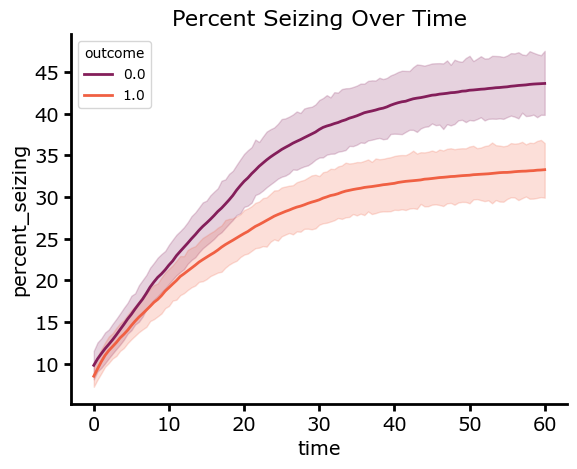

In [232]:
sns.lineplot(
    data=long_df[long_df.Focality != 'diffuse'],
    x="time",
    y="percent_seizing",
    hue="outcome",
    legend=True,
    palette = 'rocket',
    # hue_order=['false','true']
)
plt.title("Percent Seizing Over Time")
sns.despine()
plt.show()

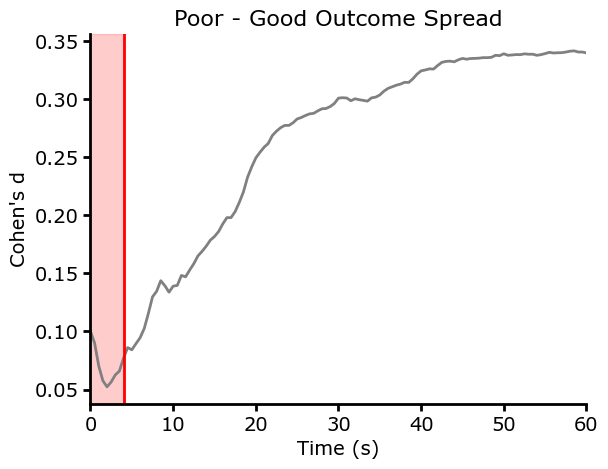

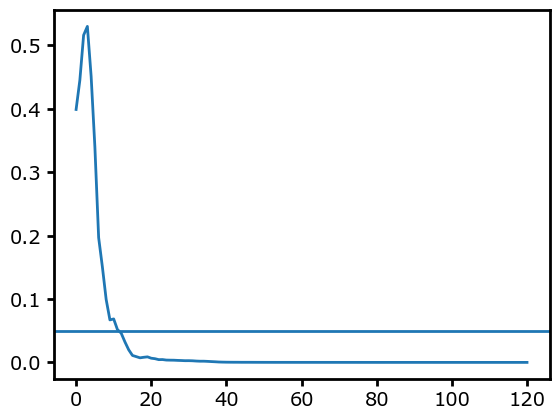

In [233]:
long_df_outcome = long_df[long_df.Focality != 'diffuse']
outcome_effect = [cohens_d(long_df_outcome[(long_df_outcome.outcome == False) & (long_df_outcome.time == t)].percent_seizing,
                           long_df_outcome[(long_df_outcome.outcome == True) & (long_df_outcome.time == t)].percent_seizing)
                           for t in time_points]
outcome_sig = [sc.stats.mannwhitneyu(long_df_outcome[(long_df_outcome.outcome == False) & (long_df_outcome.time == t)].percent_seizing,
                           long_df_outcome[(long_df_outcome.outcome == True) & (long_df_outcome.time == t)].percent_seizing)[1]
                           for t in time_points]
plt.plot(time_points,outcome_effect,color='gray')
plt.xlim([0,60])
plt.axvspan(0,4,color='red',alpha=.2)
plt.axvline(4,color='red')
plt.ylabel('Cohen\'s d')
plt.xlabel('Time (s)')
plt.title('Poor - Good Outcome Spread')
sns.despine()
plt.figure()
plt.plot(outcome_sig)
plt.axhline(0.05)

### Focality

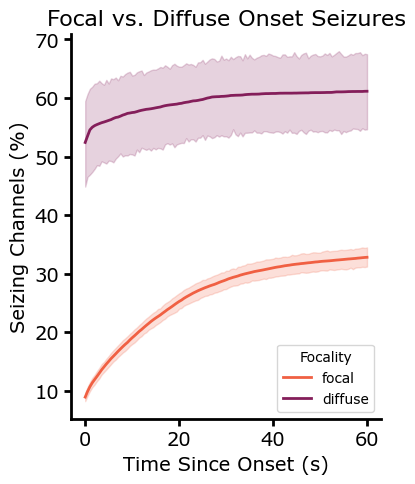

In [234]:
_,ax = plt.subplots(figsize=(4,5))
sns.lineplot(
    data=long_df,
    x="time",
    y="percent_seizing",
    hue="Focality",
    legend=True,
    palette = 'rocket_r',
    # style='laterality'
    # hue_order=['false','true']
)
plt.title("Focal vs. Diffuse Onset Seizures")
plt.ylabel('Seizing Channels (%)')
plt.xlabel('Time Since Onset (s)')
sns.despine()
plt.savefig(ospj(figpath,'focality_seizure_spread.pdf'),bbox_inches='tight')

In [235]:
pt_long_df = long_df[long_df.time==5].groupby(['patient']).agg({'percent_seizing':lambda x: np.percentile(x,50),
                                                           'isFocal':'max',
                                                           'outcome':'mean',
                                                           'onset':'max',
                                                           "Focality":'max',
                                                           "laterality":'max',
                                                           }).reset_index()

In [236]:
from functools import reduce
mdl_df = summary_df_wmeta.groupby('patient').agg({
    'alt_focal':'max',
    'ieeg_isFocal':'max',
    'all_focal':'max',
    'fiveSenseScore':'mean',
    'spread_channels':lambda x: len(reduce(np.union1d,x)),
    'onset_channels':lambda x: len(reduce(np.union1d,x)),
    'all_channels':lambda x: len(reduce(np.union1d,x))}).reset_index()

In [237]:
mdl_df['percent_seizing'] = mdl_df['spread_channels']/mdl_df['all_channels']*100
mdl_df['Focality'] = mdl_df['all_focal']
mdl_df = mdl_df[mdl_df['Focality'] != 'multifocal']

(0.0, 100.0)

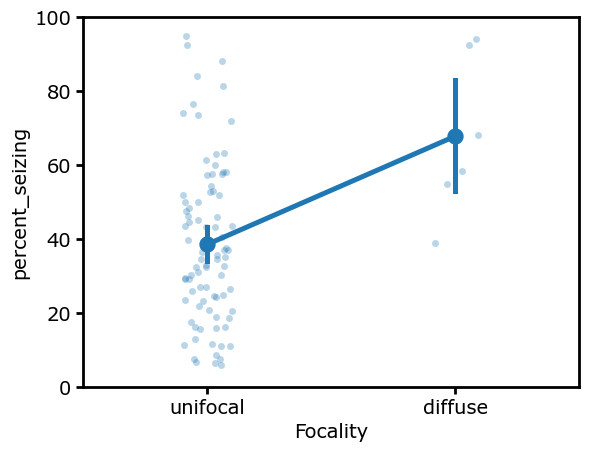

In [238]:
sns.pointplot(mdl_df,x='Focality',y='percent_seizing')
sns.stripplot(mdl_df,x='Focality',y='percent_seizing',alpha=0.3)
plt.ylim([0,100])

In [239]:
# mdl_df = pt_long_df
# mdl_df[mdl_df.Focality == 'diffuse']
# mdl_df = mdl_df[~mdl_df.patient.isin(['HUP100','HUP110'])]

In [240]:
# from sklearn.tree import DecisionTreeClassifier
all_preds = []
all_predscontrol = []
all_preds_combine = []
all_preds = np.zeros((mdl_df.patient.nunique(),3,2))
for i_pt,pt in enumerate(mdl_df.patient.unique()):
    X_train = mdl_df[mdl_df.patient != pt]
    X_test = mdl_df[mdl_df.patient == pt]
    y_train = X_train[['Focality']] == 'unifocal'
    y_test = X_test[['Focality']] == 'unifocal'
    for i,feat in enumerate([['percent_seizing'],['fiveSenseScore'],['percent_seizing','fiveSenseScore']]):
        clf = LogisticRegression(
            penalty=None,
            class_weight='balanced'
            )
        # clf.fit(X_train[['percent_seizing']],y_train.to_numpy().ravel())
        # y_pred = clf.predict_proba(X_test[['percent_seizing']])
        clf.fit(X_train[feat],y_train.to_numpy().ravel())
        y_pred = clf.predict_proba(X_test[feat])
        all_preds[i_pt,i,:] = [y_test.to_numpy()[0][0],y_pred[0][1]]
        # all_preds.append()
# all_preds = np.array(all_preds)
# roc_auc_score(all_preds[:,0],all_preds[:,1])

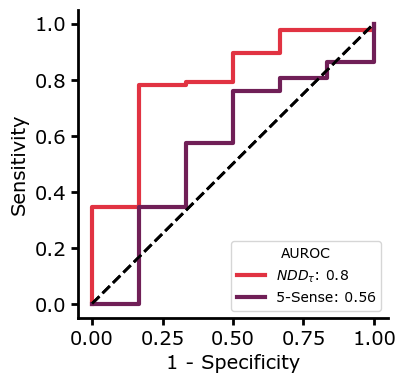

In [241]:
label_strs = ['$NDD_{\\tau}$','5-Sense']#,'NDD+5']
colors = np.array(sns.color_palette('rocket_r',as_cmap=False))[[2,4,]]
fig,ax = plt.subplots(figsize=(4,4))
for i in range(2):
    plot_preds = np.squeeze(all_preds[:,i,:])
    fpr,tpr,thresholds = roc_curve(plot_preds[:,0],plot_preds[:,1])
    # plt.figure()
    plt.plot(fpr,tpr,c=colors[i],linewidth=3, label=label_strs[i]+f': {np.round(roc_auc_score(plot_preds[:,0],plot_preds[:,1]),2)}')
    plt.plot([0,1],[0,1],c='black',linewidth=2,linestyle='--')
    sns.despine()
    plt.ylabel('Sensitivity')
    plt.xlabel('1 - Specificity')
    plt.legend(title='AUROC')
    # plt.text(0.7,.2,f'AUROC: {np.round(roc_auc_score(plot_preds[:,0],plot_preds[:,1]),2)}',fontsize=16)
    plt.savefig(ospj(figpath,'diffuse_detection_roc.pdf'),bbox_inches='tight')




MannwhitneyuResult(statistic=354036.5, pvalue=2.033405534832931e-46)
2.471225936518737
85.18518518518519 4.385964912280701


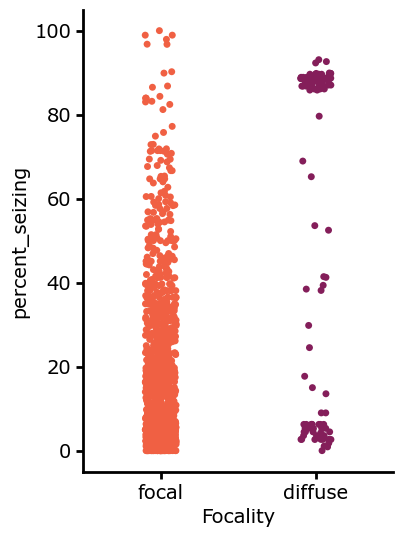

In [299]:
plt.figure(figsize=(4,6))
x = long_df[(long_df.time == 10)].groupby('patient').agg({'Focality':'max','percent_seizing':'max','Focality':'max'})
# sns.stripplot(x,x='Focality',y='percent_seizing',hue='Focality',palette='rocket_r')#,width=0.2,gap=-3)
sns.stripplot(long_df[(long_df.time == 10)],x='Focality',y='percent_seizing',hue='Focality',palette='rocket_r',
# width=0.2,gap=-3
)


print(sc.stats.mannwhitneyu(long_df[(long_df.time <= 1)&(long_df.Focality == 'focal')].percent_seizing,
                      long_df[(long_df.time <= 1)&(long_df.Focality == 'diffuse')].percent_seizing))
# long_df[(long_df.time <= 0)&(long_df.isFocal == False)].percent_seizing.mean() - long_df[(long_df.time <= 0)&(long_df.isFocal == True)].percent_seizing.mean()
print(cohens_d(long_df[(long_df.time <= 1)&(long_df.Focality == 'diffuse')].percent_seizing,
                      long_df[(long_df.time <= 1)&(long_df.Focality == 'focal')].percent_seizing))
print(long_df[(long_df.time <= 1)&(long_df.Focality == 'diffuse')].percent_seizing.median(),
      long_df[(long_df.time <= 1)&(long_df.Focality == 'focal')].percent_seizing.median())
sns.despine()

## Seizure Similarity

### Onset Similarity

p-value annotation legend:
      ns: 1.00e-01 < p <= 1.00e+00
       x: 5.00e-02 < p <= 1.00e-01
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

unifocal vs. multifocal: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.297e-02 U_stat=1.594e+03
(0.02297256082106729, 1594.0, 0.6386217948717948)
0.4921214071653724
0.38865782579679176


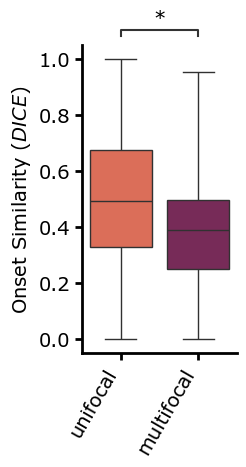

In [98]:
plt.figure(figsize=(2,4))
plt.xticks(rotation=60,ha='right')
plot_similarity_df_wmeta = similarity_df_wmeta[similarity_df_wmeta.all_focal != 'diffuse']
ax = sns.boxplot(plot_similarity_df_wmeta,x='all_focal',y='avg_dice_similarity',hue='all_focal',palette='rocket_r',whis=100,width=0.2,gap=-3)
sns.despine()
annotator = Annotator(ax,[('unifocal','multifocal')],data=plot_similarity_df_wmeta,order=['unifocal','multifocal'],x='all_focal',y='avg_dice_similarity')
annotator.configure(test='Mann-Whitney',
        comparisons_correction="Benjamini-Hochberg",
        loc='outside',
        text_format='star',
        fontsize=14,
        pvalue_thresholds=[[1e-4, "****"], [1e-3, "***"],
                        [1e-2, "**"], [0.05, "*"], [0.1, "x"],[1, "ns"]])
annotator.apply_and_annotate()
u,p = sc.stats.mannwhitneyu(similarity_df_wmeta.avg_dice_similarity[similarity_df_wmeta.all_focal == 'unifocal'],
                      similarity_df_wmeta.avg_dice_similarity[similarity_df_wmeta.all_focal == 'multifocal'])
plt.ylabel('Onset Similarity ($DICE$)')
plt.xlabel('')
plt.ylim([-.05,1.05])
plt.savefig(ospj(figpath,'onset_similarity.pdf'),bbox_inches='tight')

print(get_nparam_stats(similarity_df_wmeta,'all_focal','unifocal','multifocal','avg_dice_similarity'))
print(similarity_df_wmeta.avg_dice_similarity[similarity_df_wmeta.all_focal == 'unifocal'].median())
print(similarity_df_wmeta.avg_dice_similarity[similarity_df_wmeta.all_focal == 'multifocal'].median())

In [99]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import average_precision_score
clf = LogisticRegressionCV(refit=True)
X = plot_similarity_df_wmeta[['avg_spearman','fiveSenseScore']]
y = plot_similarity_df_wmeta.all_focal == 'unifocal'
clf.fit(X,y)
clf.score(X,y)
preds = clf.predict_proba(X)
print(average_precision_score(y,clf.predict(X)))
# print(clf.predict())

0.7646178383020488


p-value annotation legend:
      ns: 1.00e-01 < p <= 1.00e+00
       x: 5.00e-02 < p <= 1.00e-01
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

unifocal vs. multifocal: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.443e-04 U_stat=1.826e+03
(0.00014431216144024974, 1826.0, 0.7315705128205128)


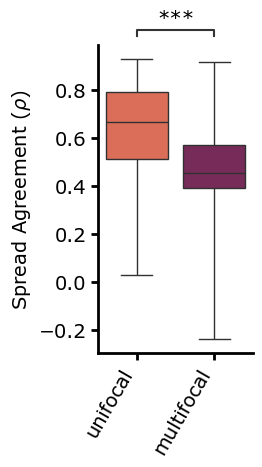

In [100]:
plt.figure(figsize=(2,4))
plot_similarity_df_wmeta = similarity_df_wmeta[similarity_df_wmeta.all_focal != 'diffuse']
ax = sns.boxplot(plot_similarity_df_wmeta,x='all_focal',y='avg_spearman',hue='all_focal',palette='rocket_r',whis=100,width=0.2,gap=-3)
sns.despine()
plt.xticks(rotation = 60, ha='right')
plt.xlabel('')
# plt.ylim([-.1,1.05])
plt.ylabel('Spread Agreement ($\\rho$)')
annotator = Annotator(ax,[('unifocal','multifocal')],data=plot_similarity_df_wmeta,order=['unifocal','multifocal'],x='all_focal',y='avg_spearman')
annotator.configure(test='Mann-Whitney',
        comparisons_correction="Benjamini-Hochberg",
        loc='outside',
        text_format='star',
        fontsize=14,
        pvalue_thresholds=[[1e-4, "****"], [1e-3, "***"],
                        [1e-2, "**"], [0.05, "*"], [0.1, "x"],[1, "ns"]])
annotator.apply_and_annotate()
plt.savefig(ospj(figpath,'spread_similarity.pdf'),bbox_inches='tight')

sc.stats.mannwhitneyu(similarity_df_wmeta.avg_spearman[similarity_df_wmeta.all_focal == 'unifocal'],
                      similarity_df_wmeta.avg_spearman[similarity_df_wmeta.all_focal == 'multifocal'])
print(get_nparam_stats(similarity_df_wmeta,'all_focal','unifocal','multifocal','avg_spearman'))

In [101]:
all_preds = []
all_predscontrol = []
all_preds_combine = []
all_preds = np.zeros((plot_similarity_df_wmeta.patient.nunique(),3,2))
for i_pt,pt in enumerate(plot_similarity_df_wmeta.patient.unique()):
    X_train = plot_similarity_df_wmeta[plot_similarity_df_wmeta.patient != pt]
    X_test = plot_similarity_df_wmeta[plot_similarity_df_wmeta.patient == pt]
    y_train = X_train[['all_focal']] == 'unifocal'
    y_test = X_test[['all_focal']] == 'unifocal'
    for i,feat in enumerate([['avg_spearman'],['fiveSenseScore'],['avg_spearman','fiveSenseScore']]):
        clf = LogisticRegression(
            penalty=None,
            class_weight='balanced'
            )
        # clf.fit(X_train[['percent_seizing']],y_train.to_numpy().ravel())
        # y_pred = clf.predict_proba(X_test[['percent_seizing']])
        clf.fit(X_train[feat],y_train.to_numpy().ravel())
        y_pred = clf.predict_proba(X_test[feat])
        all_preds[i_pt,i,:] = [y_test.to_numpy()[0][0],y_pred[0][1]]

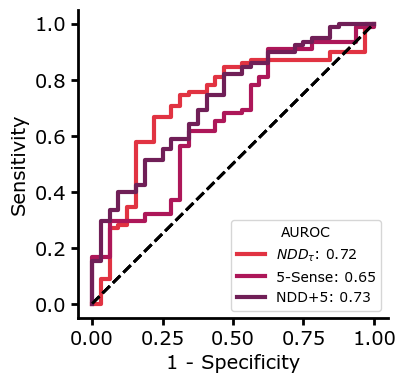

In [102]:
label_strs = ['$NDD_{\\tau}$','5-Sense','NDD+5']
colors = np.array(sns.color_palette('rocket_r',as_cmap=False))[[2,3,4]]
fig,ax = plt.subplots(figsize=(4,4))
for i in range(3):
    plot_preds = np.squeeze(all_preds[:,i,:])
    fpr,tpr,thresholds = roc_curve(plot_preds[:,0],plot_preds[:,1])
    # plt.figure()
    plt.plot(fpr,tpr,c=colors[i],linewidth=3, label=label_strs[i]+f': {np.round(roc_auc_score(plot_preds[:,0],plot_preds[:,1]),2)}')
    plt.plot([0,1],[0,1],c='black',linewidth=2,linestyle='--')
    sns.despine()
    plt.ylabel('Sensitivity')
    plt.xlabel('1 - Specificity')
    plt.legend(title='AUROC')
    # plt.text(0.7,.2,f'AUROC: {np.round(roc_auc_score(plot_preds[:,0],plot_preds[:,1]),2)}',fontsize=16)
    plt.savefig(ospj(figpath,'multifocal_detection_roc.pdf'),bbox_inches='tight')

## Unpacking the dynamics of seizure similarity

In [73]:
pair_df = pd.read_pickle(ospj(prodatapath,'pair_similarity_analysis.pkl'))
pair_df_wmeta = pair_df.merge(pt_metadata_df,how='inner',on=['patient'])

In [74]:
pair_df_wmeta[['onset_dice','spread_rank','temporal_distance']] = pair_df_wmeta[['onset_dice','spread_rank','temporal_distance']].astype(float)

### Single Patient Examples

<Axes: xlabel='temporal_distance', ylabel='spread_rank'>

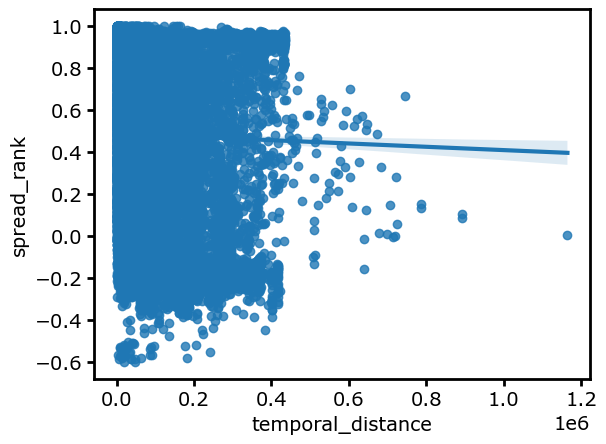

In [75]:
sns.regplot(pair_df_wmeta,x='temporal_distance',y='spread_rank')

<Axes: xlabel='temporal_distance', ylabel='spread_rank'>

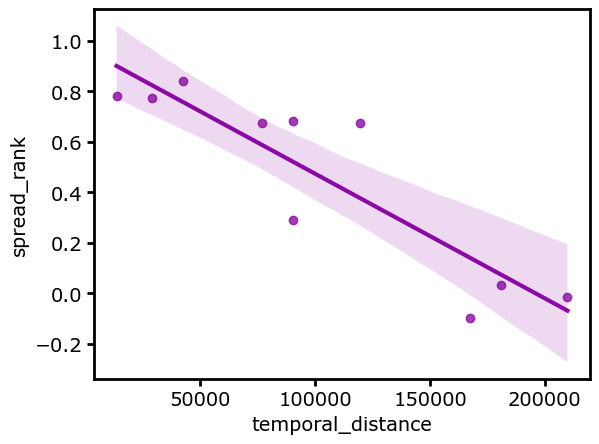

In [76]:
sns.regplot(pair_df_wmeta[pair_df_wmeta.patient=='HUP138'],x='temporal_distance',y='spread_rank',color=sns.color_palette('plasma')[1])

<Axes: xlabel='temporal_distance', ylabel='onset_dice'>

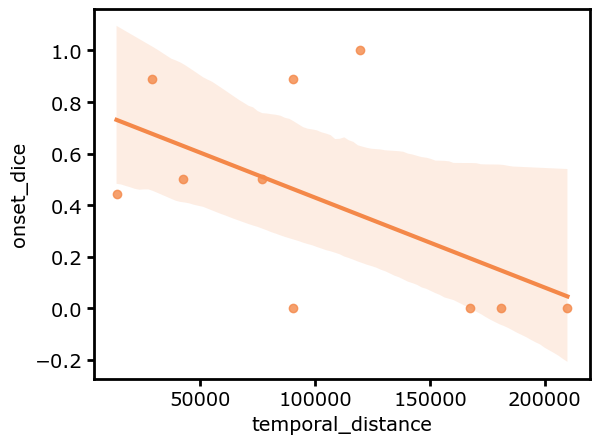

In [77]:
sns.regplot(pair_df_wmeta[pair_df_wmeta.patient=='HUP138'],x='temporal_distance',y='onset_dice',color=sns.color_palette('plasma')[4])

### Population trends in dynamic seizure similarity

In [78]:
def corr_func(group):
    rank_r,rank_p = spearmanr(group.temporal_distance,group.spread_rank,alternative='less')
    dice_r,dice_p = spearmanr(group.temporal_distance,group.onset_dice,alternative='less')

    return pd.Series([dice_r,rank_r,dice_p,rank_p],index=['dice_r','rank_r','dice_p','rank_p'])
all_pt_temp_ps = pair_df_wmeta.groupby('patient').apply(corr_func) + 1e-50
all_pt_temp_ps = all_pt_temp_ps.dropna(subset=['dice_r','rank_r'],axis=0)
all_pt_temp_ps = all_pt_temp_ps.merge(pt_metadata_df,on='patient')

/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_43924/4202347508.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  all_pt_temp_ps = pair_df_wmeta.groupby('patient').apply(corr_func) + 1e-50


<Axes: xlabel='rho'>

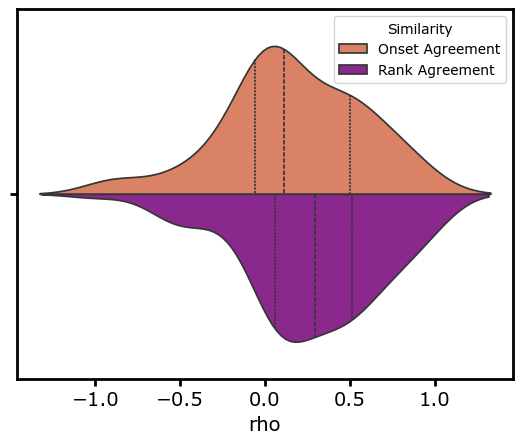

In [79]:
all_pt_temp_ps[['Onset Agreement','Rank Agreement']] = all_pt_temp_ps[['dice_r','rank_r']]*-1
all_pt_temp_ps_long = all_pt_temp_ps[['Onset Agreement','Rank Agreement','alt_focal']].melt(id_vars='alt_focal',value_name='rho',var_name='Similarity')
sns.violinplot(all_pt_temp_ps_long,x='rho',hue='Similarity',palette='plasma_r',split=True,inner='quart')

In [80]:
cohens_d(all_pt_temp_ps['Onset Agreement'],all_pt_temp_ps['Rank Agreement'])

-0.27991216892594056

In [81]:
sc.stats.wilcoxon(all_pt_temp_ps['dice_r'],all_pt_temp_ps['rank_r'])

WilcoxonResult(statistic=1747.5, pvalue=0.002203793837695126)

In [82]:
print(sc.stats.wilcoxon(all_pt_temp_ps['dice_r']))
print(sc.stats.combine_pvalues(all_pt_temp_ps['dice_p']))


WilcoxonResult(statistic=1553.5, pvalue=8.528744116118573e-05)
SignificanceResult(statistic=1641.1940547699685, pvalue=5.429056271626988e-220)


In [83]:
print(sc.stats.wilcoxon(all_pt_temp_ps['rank_r']))
print(sc.stats.combine_pvalues(all_pt_temp_ps['rank_p']))

WilcoxonResult(statistic=867.5, pvalue=9.19121786200706e-10)
SignificanceResult(statistic=2409.773454351152, pvalue=0.0)


<Axes: xlabel='alt_focal', ylabel='rho'>

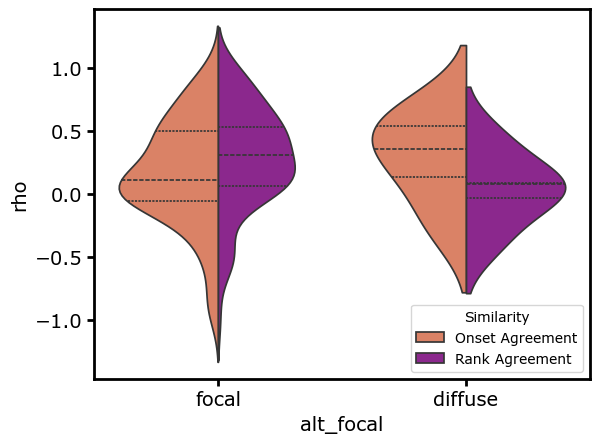

In [84]:
sns.violinplot(all_pt_temp_ps_long,y='rho',hue='Similarity',x='alt_focal',palette='plasma_r',split=True,inner='quart')

### Unpacking the relationship between onset, spread, and time

In [85]:
pair_df_wmeta_lme = pair_df_wmeta.copy()
pair_df_wmeta_lme[['onset_dice', 'spread_rank','temporal_distance']] = pair_df_wmeta_lme[['onset_dice', 'spread_rank','temporal_distance']].astype(float)
pair_df_wmeta_lme[['onset_dice', 'spread_rank']] = pair_df_wmeta_lme[['onset_dice', 'spread_rank']].astype(float) *-1
pair_df_wmeta_lme = pair_df_wmeta_lme.dropna(axis=0)
pair_df_wmeta_lme['patient'] = pair_df_wmeta_lme['patient'].astype('category')
# pair_df_wmeta_lme = pair_df_wmeta_lme.sort_values('patient')

In [86]:
pair_df_wmeta['spread_rank'].dtype

dtype('float64')

In [87]:
# temporal_distance ~ onst_dice + (1 + onset_dice|patient)
reg = smf.mixedlm(
    "temporal_distance ~ onset_dice",          # Fixed effects formula
    pair_df_wmeta_lme,                              # DataFrame
    groups=pair_df_wmeta_lme['patient'],            # Grouping variable
    re_formula="~onset_dice"          # Random slope for 'explanatory'
).fit()
print(reg.summary())

                       Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       temporal_distance
No. Observations:         778           Method:                   REML             
No. Groups:               37            Scale:                    15829511497.6134 
Min. group size:          1             Log-Likelihood:           -10277.7921      
Max. group size:          136           Converged:                Yes              
Mean group size:          21.0                                                     
-----------------------------------------------------------------------------------
                            Coef.       Std.Err.    z   P>|z|   [0.025     0.975]  
-----------------------------------------------------------------------------------
Intercept                   157957.302  33759.577 4.679 0.000  91789.747 224124.856
onset_dice                   33506.372  49333.981 0.679 0.497 -63186.454 130199.198
Group Var      

In [88]:
# temporal_distance ~ spread_rank + (1 + spread_rank|patient)
reg = smf.mixedlm(
    "temporal_distance ~ spread_rank",          # Fixed effects formula
    pair_df_wmeta_lme,                              # DataFrame
    groups=pair_df_wmeta_lme['patient'],            # Grouping variable
    re_formula="~spread_rank"          # Random slope for 'explanatory'
).fit()
print(reg.summary())

                       Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        temporal_distance
No. Observations:        778            Method:                    REML             
No. Groups:              37             Scale:                     13989742832.4863 
Min. group size:         1              Log-Likelihood:            -10218.6632      
Max. group size:         136            Converged:                 Yes              
Mean group size:         21.0                                                       
------------------------------------------------------------------------------------
                             Coef.       Std.Err.    z   P>|z|   [0.025     0.975]  
------------------------------------------------------------------------------------
Intercept                    294179.308  55753.740 5.276 0.000 184903.985 403454.631
spread_rank                  237315.117  66334.760 3.578 0.000 107301.376 367328.858
Grou

In [89]:
reg = smf.mixedlm(
    "temporal_distance ~ onset_dice + spread_rank",          # Fixed effects formula
    pair_df_wmeta_lme,                              # DataFrame
    groups=pair_df_wmeta_lme['patient'],            # Grouping variable
    re_formula="~onset_dice + spread_rank"          # Random slope for 'explanatory'
).fit()
print(reg.summary())

/Users/wojemann/Documents/CNT/DSOSD/DSOSD_env/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/wojemann/Documents/CNT/DSOSD/DSOSD_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


                           Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          temporal_distance
No. Observations:           778              Method:                      REML             
No. Groups:                 37               Scale:                       13562844211.9015 
Min. group size:            1                Log-Likelihood:              -10196.5001      
Max. group size:            136              Converged:                   Yes              
Mean group size:            21.0                                                           
-------------------------------------------------------------------------------------------
                                  Coef.       Std.Err.    z    P>|z|    [0.025     0.975]  
-------------------------------------------------------------------------------------------
Intercept                         288631.772  52239.951  5.525 0.000  186243.350 391020.193
onset_dice     

In [90]:
reg = smf.mixedlm(
    "spread_rank ~ onset_dice",          # Fixed effects formula
    pair_df_wmeta_lme,                              # DataFrame
    groups=pair_df_wmeta_lme['patient'],            # Grouping variable
    re_formula="~onset_dice"          # Random slope for 'explanatory'
).fit()
pair_df_wmeta_lme['residuals'] = reg.resid
print(reg.summary())

              Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   spread_rank
No. Observations:     778       Method:               REML       
No. Groups:           37        Scale:                0.0215     
Min. group size:      1         Log-Likelihood:       310.5873   
Max. group size:      136       Converged:            Yes        
Mean group size:      21.0                                       
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              -0.444    0.057 -7.834 0.000 -0.555 -0.333
onset_dice              0.333    0.076  4.369 0.000  0.183  0.482
Group Var               0.090    0.188                           
Group x onset_dice Cov  0.094    0.227                           
onset_dice Var          0.137    0.320                           



In [91]:
reg = smf.mixedlm(
    "temporal_distance ~ residuals",          # Fixed effects formula
    pair_df_wmeta_lme,                              # DataFrame
    groups=pair_df_wmeta_lme['patient'],            # Grouping variable
    re_formula="~residuals"          # Random slope for 'explanatory'
).fit()
print(reg.summary())

                      Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       temporal_distance
No. Observations:        778           Method:                   REML             
No. Groups:              37            Scale:                    16637457362.2672 
Min. group size:         1             Log-Likelihood:           -10278.4282      
Max. group size:         136           Converged:                Yes              
Mean group size:         21.0                                                     
----------------------------------------------------------------------------------
                           Coef.       Std.Err.    z   P>|z|   [0.025     0.975]  
----------------------------------------------------------------------------------
Intercept                  141552.735  20103.113 7.041 0.000 102151.357 180954.113
residuals                  237689.294  64383.961 3.692 0.000 111499.049 363879.539
Group Var             11979

## Relating onset and spread similarity to NDD

### Seizure pair level

In [92]:
lm_df_pair = pd.merge(ndd_df,pair_df_wmeta,how='inner',on=['patient','onset_1','onset_2','temporal_distance']).dropna(subset=['dtw_distance','onset_dice','spread_rank'])

In [93]:
np.corrcoef(lm_df_pair.onset_dice,lm_df_pair.spread_rank)

array([[1.        , 0.59156448],
       [0.59156448, 1.        ]])

In [94]:
reg = smf.ols('dtw_distance ~  spread_rank',lm_df_pair)
print(reg.fit().summary())

                            OLS Regression Results                            
Dep. Variable:           dtw_distance   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     23.09
Date:                Mon, 19 May 2025   Prob (F-statistic):           1.55e-06
Time:                        16:51:39   Log-Likelihood:            -1.9335e+05
No. Observations:               19881   AIC:                         3.867e+05
Df Residuals:                   19879   BIC:                         3.867e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    3198.1794     45.614     70.114      

In [95]:
reg = smf.ols('dtw_distance ~  onset_dice',lm_df_pair)
print(reg.fit().summary())

                            OLS Regression Results                            
Dep. Variable:           dtw_distance   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     814.8
Date:                Mon, 19 May 2025   Prob (F-statistic):          1.15e-175
Time:                        16:51:40   Log-Likelihood:            -1.9297e+05
No. Observations:               19881   AIC:                         3.859e+05
Df Residuals:                   19879   BIC:                         3.860e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4302.8942     52.810     81.479      0.0

In [96]:
reg = smf.mixedlm(
    "dtw_distance ~ onset_dice + spread_rank",          # Fixed effects formula
    lm_df_pair,                              # DataFrame
    groups=lm_df_pair['patient'],            # Grouping variable
    re_formula="~onset_dice + spread_rank"          # Random slope for 'explanatory'
).fit()
print(reg.summary())

                        Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          dtw_distance
No. Observations:           19881            Method:                      REML        
No. Groups:                 120              Scale:                       5624005.3489
Min. group size:            1                Log-Likelihood:              -183245.5521
Max. group size:            5050             Converged:                   Yes         
Mean group size:            165.7                                                     
--------------------------------------------------------------------------------------
                                 Coef.       Std.Err.   z    P>|z|   [0.025    0.975] 
--------------------------------------------------------------------------------------
Intercept                         10335.301  1040.931  9.929 0.000  8295.113 12375.489
onset_dice                        -4288.848  1598.516 -2.683 0.007 -

### Patient level

In [97]:
lm_df_pt = pd.merge(all_pt_ndd_ps,all_pt_temp_ps,on=['patient'])
lm_df_pt[['dice_r','rank_r']] = lm_df_pt[['dice_r','rank_r']]*-1

NameError: name 'all_pt_ndd_ps' is not defined

In [98]:
lm_df_pt_long = lm_df_pt[['dtw_r','dice_r','rank_r']].melt()
sns.swarmplot(lm_df_pt_long,x='variable',y='value',hue='variable')
plt.ylabel('Temporal Modulation of Seizure Dissimilarity')
sns.despine()

NameError: name 'lm_df_pt' is not defined

In [99]:
sns.regplot(lm_df_pt,x='dice_r',y='rank_r')
reg = smf.ols('rank_r ~  dice_r',lm_df_pt)
reg = reg.fit()
print(reg.summary())
lm_df_pt['residuals'] = reg.resid

NameError: name 'lm_df_pt' is not defined

In [100]:
sns.regplot(lm_df_pt,x='residuals',y='dtw_r')
reg = smf.ols('dtw_r ~  residuals',lm_df_pt)
print(reg.fit().summary())

NameError: name 'lm_df_pt' is not defined

In [101]:
sns.regplot(lm_df_pt,x='dice_r',y='dtw_r')
reg = smf.ols('dtw_r ~  dice_r',lm_df_pt)
print(reg.fit().summary())

NameError: name 'lm_df_pt' is not defined

## Spread patterns across the epileptiform spectrum

### Seizure severities

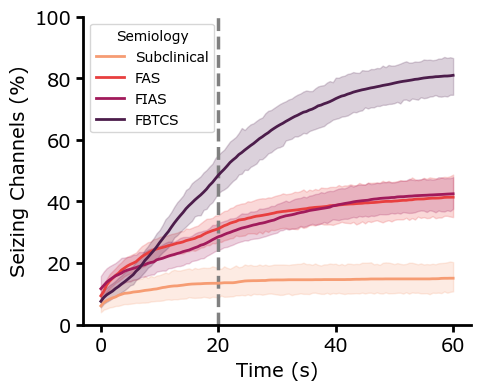

In [112]:
_,ax = plt.subplots(figsize=(5,4))
ax.axvline(20,linewidth=2.5,linestyle='--',c='gray')
sz_types = ['Subclinical','FAS','FIAS','FBTCS']
sns.lineplot(
    data=long_df[long_df.Focality != 'diffuse'],
    x="time",
    y="percent_seizing",
    hue="Semiology",
    legend=True,
    palette = 'rocket_r',
    hue_order=['Subclinical','FAS','FIAS','FBTCS']
)
plt.ylabel('Seizing Channels (%)')
plt.xlabel('Time (s)')
plt.ylim([0,100])
# plt.title("Percent Seizing Over Time")
sns.despine()
plt.savefig(ospj(figpath,'seizure_severity.pdf'),bbox_inches='tight')
plt.show()

In [106]:
long_df_20 = long_df[long_df['time'] == 20]
wide_df = long_df_20.groupby('Semiology')['percent_seizing'].apply(list)
sc.stats.kruskal(*wide_df)

KruskalResult(statistic=54.45337107879525, pvalue=8.980898113986764e-12)

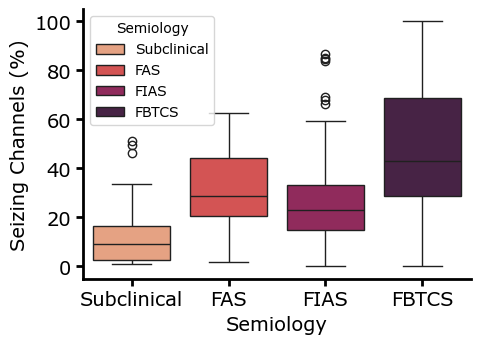

In [ ]:
plt.figure(figsize=(5,3.5))
sns.boxplot(long_df_20,x='Semiology',hue='Semiology',palette='rocket_r',y='percent_seizing',
            order=['Subclinical','FAS','FIAS','FBTCS'],
            hue_order = ['Subclinical','FAS','FIAS','FBTCS'])
plt.ylabel('Seizing Channels (%)')
plt.xlabel('Semiology')

sns.despine()
plt.savefig(ospj(figpath,'seizure_severity_discrete.pdf'),bbox_inches='tight')


In [ ]:
all_ps = []
for i in range(len(sz_types)-1):
    x = long_df_20[long_df_20.Semiology == sz_types[i]].percent_seizing
    y  = long_df_20[long_df_20.Semiology == sz_types[i+1]].percent_seizing
    print(len(x),len(y))
    print(x.mean(),y.mean())
    u,p = sc.stats.mannwhitneyu(x,y)
    print(u,p)
    all_ps.append(p)
sc.stats.false_discovery_control(all_ps)

34 50
0.05081522044732197 0.07333772363330131
643.0 0.05983536188451535
50 79
0.07333772363330131 0.1097478372932828
1987.5 0.953738467928539
79 74
0.1097478372932828 0.08475946634388445
3069.0 0.595267274530354


array([0.17950609, 0.95373847, 0.89290091])

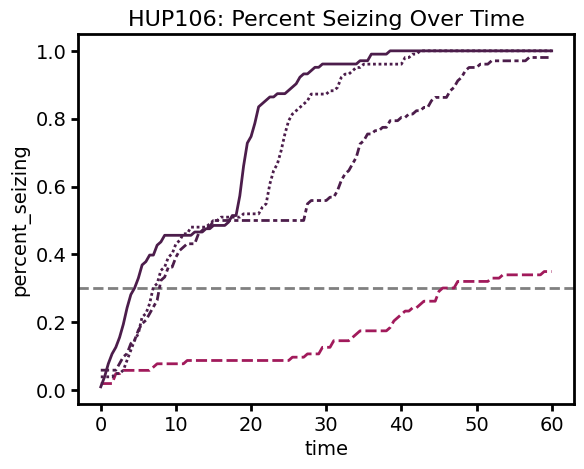

In [ ]:
plt.axhline(.3,linestyle='--',color='gray')
sns.lineplot(
    data=long_df[long_df.patient == 'HUP106'],
    x="time",
    y="percent_seizing",
    hue="Semiology",
    palette = 'rocket_r',
    hue_order=['Subclinical','FAS','FIAS','FBTCS'],
    style='onset',
    legend=False
)
plt.title("HUP106: Percent Seizing Over Time")
plt.show()

In [ ]:
sem_list = []
for pt, group in summary_df_wmeta.groupby('patient'):
    if (len(group.Semiology.unique()) > 1):# & (group['alt_focal'].iloc[0] != 'multifocal'):
        sem_list.append(group)
summary_df_wsem = pd.concat(sem_list).reset_index(drop=True)

In [ ]:
seizure_rank = np.array(['Subclinical','FAS','FIAS','FBTCS'])
summary_df_wsem['Semiology'] = pd.Categorical(summary_df_wsem['Semiology'],categories=seizure_rank,ordered=True)
summary_df_wsem = summary_df_wsem.groupby('patient').apply(lambda x: x.sort_values('Semiology')).reset_index(drop=True)

/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_57921/3425671873.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_df_wsem = summary_df_wsem.groupby('patient').apply(lambda x: x.sort_values('Semiology')).reset_index(drop=True)


In [ ]:
summary_df_wsem['max_spread'] = summary_df_wsem['fraction_seizing'].apply(lambda x: np.max(x))

In [ ]:
summary_df_wsem[['Semiology','max_spread']]

,Semiology,max_spread
0,FIAS,0.443038
1,FBTCS,1.000000
2,FBTCS,0.901235
3,FBTCS,0.876543
4,FBTCS,1.000000
...,...,...
233,Subclinical,0.008000
234,Subclinical,0.033058
235,Subclinical,0.008333
236,FIAS,0.400000


In [ ]:
x = summary_df_wsem[summary_df_wsem.patient == 'HUP107']
x

,patient,onset,onset_channels,channel_spread_rank,channel_spread_time,fraction_seizing,abs_seizing,all_channels,onset_ndd_cum,onset_ndd_ind,...,offset,source,notes,Semiology,stim induced,HUP_Patient,outcome,alt_focal,all_focal,max_spread
35,HUP107,695316.0,"[RDA01-RDA02, RDA03-RDA04, RDA02-RDA03, RDH01-...","{'LAT01-LAT02': 9, 'LAT02-LAT03': 9, 'LAT03-LA...","{'RDA01-RDA02': 0.0, 'RDA03-RDA04': 0.0, 'RDA0...","[0.019230769230769232, 0.019230769230769232, 0...","[2, 2, 2, 3, 3, 6, 6, 8, 8, 8, 8, 8, 8, 8, 8, ...","[LAT01-LAT02, LAT02-LAT03, LAT03-LAT04, LDA01-...","[[0.748167097568512, 0.6198277473449707, 0.579...","[[0.748167097568512, 0.6198277473449707, 0.579...",...,695342.15,json,,FAS,0.0,True,1.0,focal,unifocal,0.076923
36,HUP107,410233.0,"[RPT02-RPT03, RPT03-RPT04]","{'LAT01-LAT02': 57, 'LAT02-LAT03': 57, 'LAT03-...","{'RPT02-RPT03': 0.0, 'RPT03-RPT04': 2.5, 'RG07...","[0.009615384615384616, 0.009615384615384616, 0...","[1, 1, 1, 1, 1, 2, 4, 5, 6, 7, 7, 8, 9, 10, 10...","[LAT01-LAT02, LAT02-LAT03, LAT03-LAT04, LDA01-...","[[0.5108315944671631, 0.859745979309082, 0.834...","[[0.5108315944671631, 0.859745979309082, 0.834...",...,410393.75,json,,FIAS,0.0,True,1.0,focal,unifocal,0.528846
37,HUP107,430231.0,"[RAT03-RAT04, RG09-RG10, RAT02-RAT03, RG01-RG0...","{'LAT01-LAT02': 23, 'LAT02-LAT03': 23, 'LAT03-...","{'RAT03-RAT04': 0.0, 'RG09-RG10': 0.0, 'RAT02-...","[0.019230769230769232, 0.028846153846153848, 0...","[2, 3, 6, 7, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 10,...","[LAT01-LAT02, LAT02-LAT03, LAT03-LAT04, LDA01-...","[[0.5009465217590332, 0.8390968441963196, 1.05...","[[0.5009465217590332, 0.8390968441963196, 1.05...",...,430290.31,json,,FIAS,0.0,True,1.0,focal,unifocal,0.211538
38,HUP107,399391.0,"[RG02-RG03, RG03-RG04, RAT03-RAT04, RAT02-RAT0...","{'LAT01-LAT02': 32, 'LAT02-LAT03': 32, 'LAT03-...","{'RG02-RG03': 0.0, 'RG03-RG04': 0.0, 'RAT03-RA...","[0.019230769230769232, 0.019230769230769232, 0...","[2, 2, 2, 2, 3, 5, 5, 7, 7, 7, 9, 9, 10, 10, 1...","[LAT01-LAT02, LAT02-LAT03, LAT03-LAT04, LDA01-...","[[0.4748448133468628, 0.8032152056694031, 1.03...","[[0.4748448133468628, 0.8032152056694031, 1.03...",...,399471.22,json,,FIAS,0.0,True,1.0,focal,unifocal,0.298077
39,HUP107,425992.0,"[RAT02-RAT03, RAT03-RAT04, RG09-RG10, RMT03-RM...","{'LAT01-LAT02': 20, 'LAT02-LAT03': 20, 'LAT03-...","{'RAT02-RAT03': 0.0, 'RAT03-RAT04': 0.0, 'RG09...","[0.019230769230769232, 0.038461538461538464, 0...","[2, 4, 5, 6, 7, 7, 7, 7, 7, 8, 9, 9, 9, 9, 9, ...","[LAT01-LAT02, LAT02-LAT03, LAT03-LAT04, LDA01-...","[[0.4387155771255493, 0.6275765299797058, 0.89...","[[0.4387155771255493, 0.6275765299797058, 0.89...",...,426056.81,json,,FIAS,0.0,True,1.0,focal,unifocal,0.182692
40,HUP107,415979.0,"[RAT03-RAT04, RAT02-RAT03, RG09-RG10, RG01-RG0...","{'LAT01-LAT02': 29, 'LAT02-LAT03': 29, 'LAT03-...","{'RAT03-RAT04': 0.0, 'RAT02-RAT03': 0.5, 'RG09...","[0.009615384615384616, 0.019230769230769232, 0...","[1, 2, 3, 5, 6, 6, 6, 6, 6, 6, 6, 7, 8, 8, 9, ...","[LAT01-LAT02, LAT02-LAT03, LAT03-LAT04, LDA01-...","[[0.5363404154777527, 0.8728134036064148, 1.19...","[[0.5363404154777527, 0.8728134036064148, 1.19...",...,416063.77,json,,FIAS,0.0,True,1.0,focal,unifocal,0.269231
41,HUP107,395266.0,"[RPT02-RPT03, RG07-RG08, RG08-RG09, RPT03-RPT04]","{'LAT01-LAT02': 91, 'LAT02-LAT03': 98, 'LAT03-...","{'RPT02-RPT03': 0.0, 'RG07-RG08': 0.0, 'RG08-R...","[0.0196078431372549, 0.029411764705882353, 0.0...","[2, 3, 3, 3, 3, 4, 5, 6, 7, 8, 9, 9, 11, 13, 1...","[LAT01-LAT02, LAT02-LAT03, LAT03-LAT04, LDA01-...","[[0.4953180253505707, 0.7228026390075684, 0.82...","[[0.4953180253505707, 0.7228026390075684, 0.82...",...,395481.88,json,,FBTCS,0.0,True,1.0,focal,unifocal,0.460784


### Spike loading

In [ ]:
# spike_df = pd.read_csv(ospj(datapath,'hup_thresholded.csv'))
# spike_df['recruitment_latency_thresh'] /= 500 # This is the sampling rate from the spike dataset

In [ ]:
# all_spike_fts = []
# for patient in tqdm(spike_df.pt_id.unique()):
#     group = spike_df[spike_df.pt_id == patient]
#     group.loc[:,'channel_label'] = clean_labels(group['channel_label'],patient)
#     group = group[group.channel_label.isin(remove_scalp_electrodes(group.channel_label.unique()))]
#     n_seqs = group.new_spike_seq.max()
#     probabilities = group.groupby(['new_spike_seq','channel_label'])['recruitment_latency_thresh'].mean().groupby('channel_label').count()/n_seqs
#     ch_mask = group.groupby('channel_label')['recruitment_latency_thresh'].count() > (n_seqs*0.05)
#     thresh_ch_list = ch_mask[ch_mask].index
#     group = group[group.channel_label.isin(thresh_ch_list)]
#     latencies = group.groupby(['new_spike_seq','channel_label'])['recruitment_latency_thresh'].mean().groupby('channel_label').median()
#     all_spike_fts.append({'patient': patient,
#                           'latency': latencies.to_dict(),
#                           'probability': probabilities.to_dict()})
# all_spike_fts_df = pd.DataFrame(all_spike_fts)
# all_spike_fts_df.to_pickle(ospj(prodatapath,'all_spike_fts.pkl'))

In [ ]:
all_spike_fts_df = pd.read_pickle(ospj(prodatapath,'all_spike_fts.pkl'))

In [ ]:
summary_df_wspikes = summary_df_wmeta.merge(all_spike_fts_df,on='patient',how='inner')

In [ ]:
summary_df_wspikes.loc[0,'onset_ndd_ind'][0]

LA01-LA02    1.596092
LA02-LA03    2.205025
LA03-LA04    1.514484
LA04-LA05    0.775895
LA05-LA06    0.951427
               ...   
RD03-RD04    0.928609
RD04-RD05    0.930479
RD05-RD06    0.797719
RD06-RD07    0.864366
RD07-RD08    1.002658
Length: 104, dtype: float32

/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_55489/2060322493.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(labels=ax2.get_yticklabels(),color='orange')
/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_55489/2060322493.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels=ax2.get_xticklabels(),rotation=90)


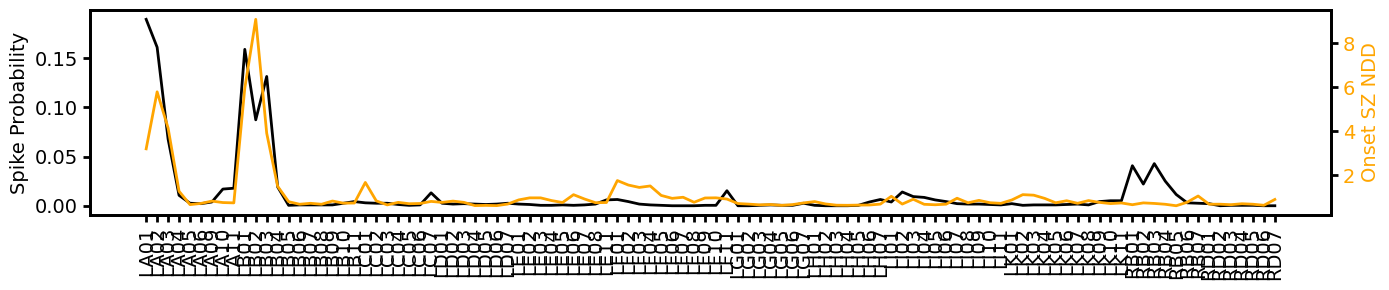

In [ ]:
row = summary_df_wspikes.loc[0,:]
onset = row.SOZ_region
patient = row.patient
outcome = row.outcome
ndd_onset_mono = row.onset_ndd_ind[3].copy()
# ndd_onset_mono = row.onset_ndd_cum[time_idx].copy()
ndd_onset_mono.index = [x.split('-')[0] for x in ndd_onset_mono.index]
all_ndd_spikes = {key: 0 for key in ndd_onset_mono.index}
for key in row.probability.keys():
    all_ndd_spikes[key] = row.probability[key]
all_ndd_spikes_df = pd.Series(all_ndd_spikes).reindex(ndd_onset_mono.index)
fig, ax1 = plt.subplots(figsize=(14,3),)
ax1.plot(all_ndd_spikes_df,color='black')
ax1.set_ylabel('Spike Probability',color='black')
ax2=ax1.twinx()
ax2.plot(ndd_onset_mono,color='orange')
ax2.set_yticklabels(labels=ax2.get_yticklabels(),color='orange')
ax2.set_ylabel('Onset SZ NDD',color='orange')
ax1.set_xticklabels(labels=ax2.get_xticklabels(),rotation=90)
plt.tight_layout()
# sns.despine()

Ok so i need to get for each spike train the average latency. I also need to get the spike probability. Maybe have an absolute threshold of number of spikes required to get included in the latency calculation. Right now the pipeline is go through each spike train and append the latency.


### Spike and seizure onset

In [ ]:
def spike_onset_func(row,time_idx = 3):
    onset = row.SOZ_region
    patient = row.patient
    outcome = row.outcome
    ndd_onset_mono = row.onset_ndd_ind[time_idx].copy()
    # ndd_onset_mono = row.onset_ndd_cum[time_idx].copy()
    ndd_onset_mono.index = [x.split('-')[0] for x in ndd_onset_mono.index]
    all_ndd_spikes = {key: 0 for key in ndd_onset_mono.index}
    for key in row.probability.keys():
        all_ndd_spikes[key] = row.probability[key]
    all_ndd_spikes_df = pd.Series(all_ndd_spikes).reindex(ndd_onset_mono.index)
    if any(ndd_onset_mono.isna()) | (len(ndd_onset_mono) < 2):
        return pd.Series([np.nan,np.nan],index=['onset_r','onset_p'])
    else:
        r,p = pearsonr(all_ndd_spikes_df,ndd_onset_mono,alternative='greater')
        return pd.Series([r,p,onset,patient,outcome],index=['onset_r','onset_p','onset','patient','outcome'])

In [ ]:
summary_df_wspikes.columns

NameError: name 'summary_df_wspikes' is not defined

In [ ]:
summary_df_wspikes.head()

In [ ]:
time_idxs = [1,3,5,10,15,20,25,30,40]
all_spike_onsets = []
all_time_idxs = []
all_onsets = []
all_pts = []
all_outcomes = []
for i in range(len(time_idxs)):
    all_onset_spike_ps = summary_df_wspikes[(summary_df_wspikes.all_focal == 'focal')& (summary_df_wspikes.SOZ_region.isin(['mesial temporal','temporal neocortical']))].apply(spike_onset_func,time_idx = i,axis=1)
    # & (summary_df_wspikes.SOZ_region != 'other cortex')
    # all_onset_spike_ps = summary_df_wspikes.apply(spike_onset_func,time_idx = i,axis=1)

    all_spike_onsets.extend(all_onset_spike_ps.onset_r.to_list())
    all_time_idxs.extend([time_idxs[i]]*len(all_onset_spike_ps))
    all_onsets.extend(all_onset_spike_ps.onset.to_list())
    all_pts.extend(all_onset_spike_ps.patient.to_list())
    all_outcomes.extend(all_onset_spike_ps.outcome.to_list())

Traceback (most recent call last):
  File "_pydevd_bundle\\pydevd_cython.pyx", line 1609, in _pydevd_bundle.pydevd_cython.handle_exception
  File "/Users/wojemann/Documents/CNT/DSOSD/DSOSD_env/lib/python3.9/site-packages/debugpy/_vendored/pydevd/pydevd.py", line 2185, in do_wait_suspend
    keep_suspended = self._do_wait_suspend(thread, frame, event, arg, trace_suspend_type, from_this_thread, frames_tracker)
  File "/Users/wojemann/Documents/CNT/DSOSD/DSOSD_env/lib/python3.9/site-packages/debugpy/_vendored/pydevd/pydevd.py", line 2254, in _do_wait_suspend
    notify_event.wait(wait_timeout)
  File "/Users/wojemann/opt/anaconda3/lib/python3.9/threading.py", line 574, in wait
    signaled = self._cond.wait(timeout)
  File "/Users/wojemann/opt/anaconda3/lib/python3.9/threading.py", line 316, in wait
    gotit = waiter.acquire(True, timeout)
KeyboardInterrupt


: 

: 

In [ ]:
spike_onset_agreement_df = pd.DataFrame(np.concatenate((np.array(all_time_idxs).reshape(-1,1),np.array(all_spike_onsets).reshape(-1,1),np.array(all_onsets).reshape(-1,1),np.array(all_pts).reshape(-1,1),np.array(all_outcomes).reshape(-1,1)),axis=1),columns=['time','spike-onset-r','onset','patient','outcome'],).dropna(axis=0)

In [ ]:
spike_onset_agreement_df['spike-onset-r'] = spike_onset_agreement_df['spike-onset-r'].astype(float)
spike_onset_agreement_df = spike_onset_agreement_df.dropna(subset=['spike-onset-r'])
spike_onset_agreement_df['time'] = spike_onset_agreement_df['time'].astype(float)

In [ ]:
onsets = ['mesial temporal','temporal neocortical']
sub_spike_df = spike_onset_agreement_df[spike_onset_agreement_df.onset.isin(onsets)]
sub_spike_df_pt = sub_spike_df.groupby(['patient','time']).agg({
                                                             'onset': 'max', 
                                                             'spike-onset-r': 'median',
                                                             'outcome':'max'
                                                            }).reset_index()
sub_spike_df_pt = sub_spike_df_pt.replace({'1.0': 'good','0.0': 'poor'})

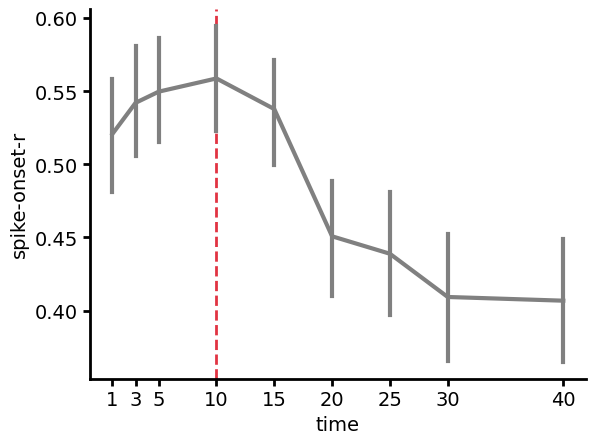

In [ ]:
plt.axvline(10,color=sns.color_palette('rocket_r')[2],linestyle='--',linewidth=2)
sns.lineplot(spike_onset_agreement_df,x='time',y='spike-onset-r',err_style='bars',color='gray',linewidth=3,err_kws={'linewidth':3})
plt.xticks(time_idxs)
sns.despine()

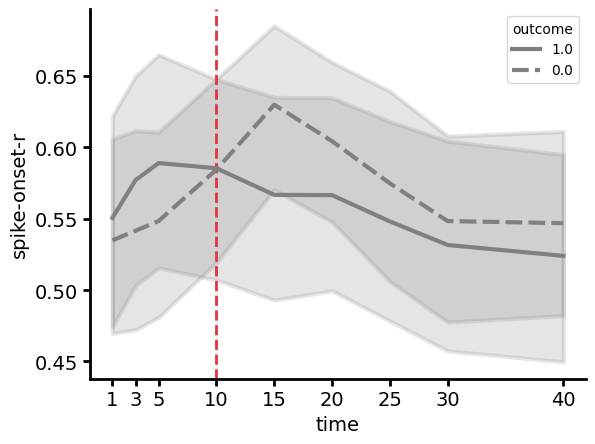

In [ ]:
plt.axvline(10,color=sns.color_palette('rocket_r')[2],linestyle='--',linewidth=2)
sns.lineplot(spike_onset_agreement_df,style='outcome',style_order=['1.0','0.0'],x='time',y='spike-onset-r',err_style='band',color='gray',linewidth=3,err_kws={'linewidth':3})
plt.xticks(time_idxs)
sns.despine()

In [ ]:
print(sc.stats.mannwhitneyu(spike_onset_agreement_df[spike_onset_agreement_df.time == 10]['spike-onset-r'],
         spike_onset_agreement_df[spike_onset_agreement_df.time == 1]['spike-onset-r']))
print(cohens_d(spike_onset_agreement_df[spike_onset_agreement_df.time == 10]['spike-onset-r'],
         spike_onset_agreement_df[spike_onset_agreement_df.time == 1]['spike-onset-r']))

MannwhitneyuResult(statistic=47436.0, pvalue=0.25131957019385764)
0.11662845333958248


In [ ]:
plot_onset_spike_ps = summary_df_wspikes[(summary_df_wspikes.all_focal == 'focal')& (summary_df_wspikes.SOZ_region.isin(['mesial temporal','temporal neocortical']))].apply(spike_onset_func,time_idx = 3,axis=1)

Text(0.5, 1.0, '')

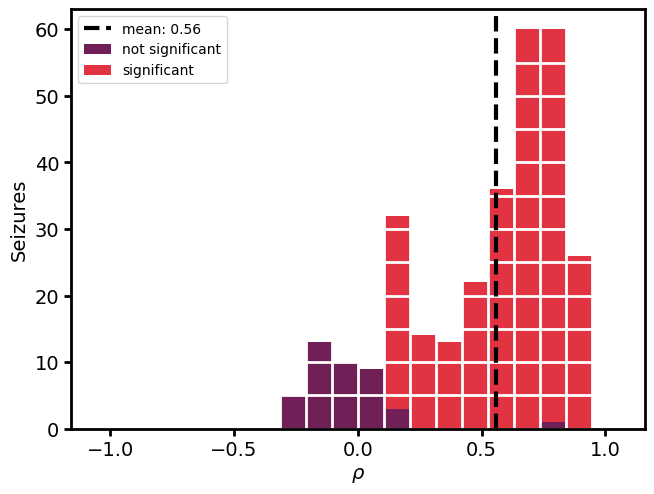

In [ ]:
_,ax=plot_sig_nsig(plot_onset_spike_ps.onset_r[plot_onset_spike_ps.onset_p < 0.05],plot_onset_spike_ps.onset_r[plot_onset_spike_ps.onset_p >= 0.05],vbox_int=5)
ax.axvline(plot_onset_spike_ps.onset_r.mean(),linestyle='--',color='black',linewidth=3,label=f'mean: {plot_onset_spike_ps.onset_r.mean():.2f}')
plt.legend()
ax.set_xlabel(r'$\rho$')
ax.set_ylabel('Seizures')
plt.title('')

In [ ]:
# onsets = ['mesial temporal','temporal neocortical','other cortex']


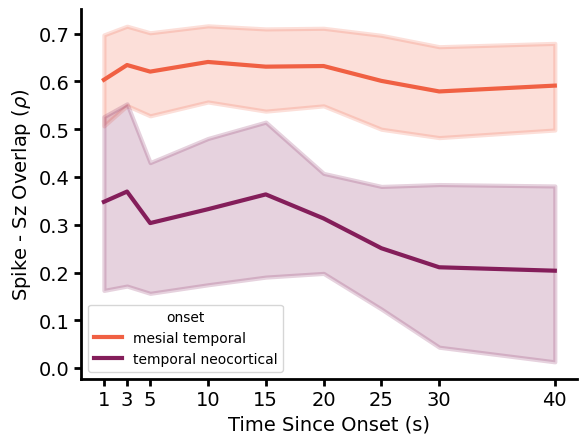

In [ ]:
sns.lineplot(sub_spike_df_pt,x='time',y='spike-onset-r',err_style='band',hue='onset',hue_order=onsets,palette='rocket_r',linewidth=3,err_kws={'linewidth':3},estimator='mean')
plt.xticks(time_idxs)
plt.xlabel('Time Since Onset (s)')
plt.ylabel(r'Spike - Sz Overlap ($\rho$)')
sns.despine()

MannwhitneyuResult(statistic=153.0, pvalue=0.040001275672727536)


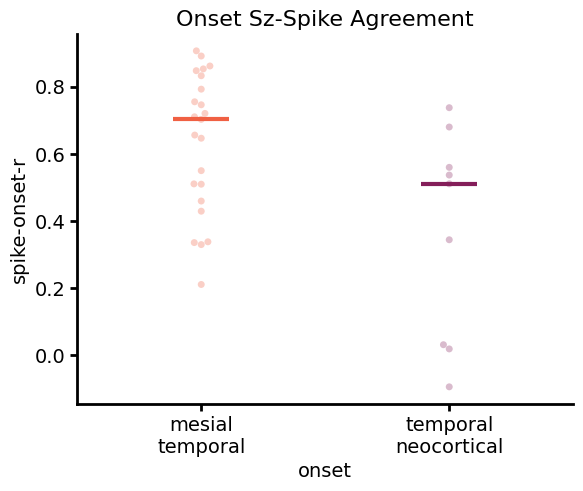

In [ ]:
# sns.boxplot(sub_spike_df[sub_spike_df.time==10],hue='onset',order=['mesial temporal','temporal neocortical','other cortex'],hue_order=['mesial temporal','temporal neocortical','other cortex'],x='onset',y='spike-onset-r',palette='rocket_r',whis=100)
sub_spike_10 = sub_spike_df_pt[sub_spike_df_pt.time==3]

ax = sns.swarmplot(sub_spike_10,hue='onset',order=onsets,
              hue_order=onsets,
              x='onset',y='spike-onset-r',
              palette='rocket_r',
              alpha=0.3)

sns.pointplot(sub_spike_10,
              hue='onset',
              palette='rocket_r',
              linestyle="none", errorbar=None,
              marker="_", markersize=40, markeredgewidth=3,
              order=onsets,
              hue_order=onsets,
              x='onset',y='spike-onset-r',
              ax = ax,
              estimator='median')
plt.title('Onset Sz-Spike Agreement')
# plt.xticks(ticks=[0,1,2],labels=['mesial\ntemporal','temporal\nneocortical','other cortex'])
plt.xticks(ticks=[0,1],labels=['mesial\ntemporal','temporal\nneocortical'])
sns.despine()
for i in range(len(onsets)):
    for j in range(i+1,len(onsets)):
        print(sc.stats.mannwhitneyu(sub_spike_10[sub_spike_10.onset == onsets[i]]['spike-onset-r'],
                        sub_spike_10[sub_spike_10.onset == onsets[j]]['spike-onset-r']))

### Outcome and Spike-Sz concordance

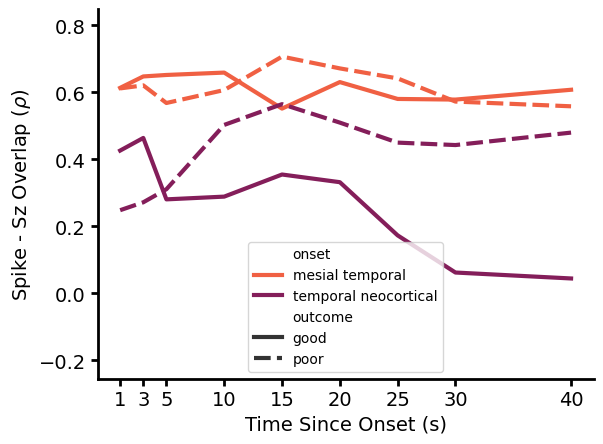

In [ ]:
sns.lineplot(sub_spike_df_pt,x='time',y='spike-onset-r',err_style='band',hue='onset',hue_order=onsets,palette='rocket_r',linewidth=3,err_kws={'linewidth':0,'alpha':0},estimator='mean',style='outcome',style_order=['good','poor'])
plt.xticks(time_idxs)
plt.xlabel('Time Since Onset (s)')
plt.ylabel(r'Spike - Sz Overlap ($\rho$)')
sns.despine()

MannwhitneyuResult(statistic=108.0, pvalue=0.03571172886492605)
-0.9631829349074675
0.72


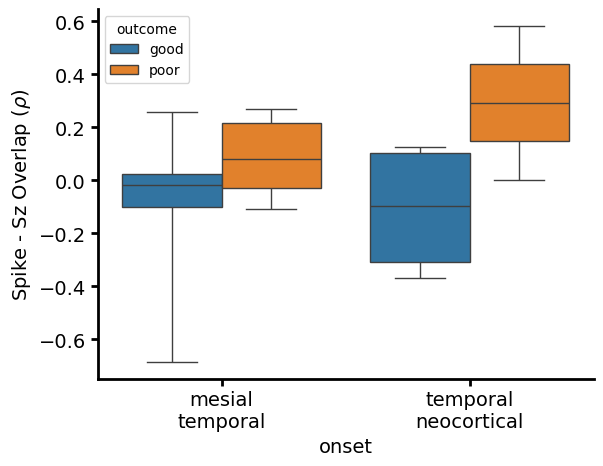

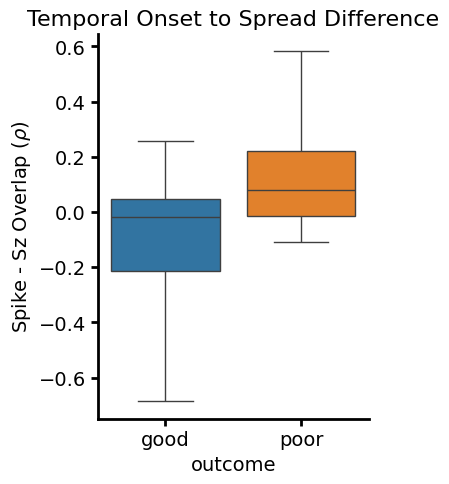

In [ ]:
sub_spike_10.loc[:,'spike-onset-r'] = sub_spike_df_pt[sub_spike_df_pt.time==15]['spike-onset-r'].to_numpy() - sub_spike_df_pt[sub_spike_df_pt.time == 3]['spike-onset-r'].to_numpy()
# sub_spike_10.loc[:,'spike-onset-r'] = sub_spike_df_pt[sub_spike_df_pt.time==15]['spike-onset-r'].to_numpy()
# sub_spike_10.loc[:,'spike-onset-r'] = sub_spike_df_pt[sub_spike_df_pt.time == 3]['spike-onset-r'].to_numpy()

ax = sns.boxplot(sub_spike_10,hue='outcome',order=onsets,hue_order=['good','poor'],
              x='onset',y='spike-onset-r',whis=100)
plt.ylabel(r'Spike - Sz Overlap ($\rho$)')
plt.xticks(ticks=[0,1],labels=['mesial\ntemporal','temporal\nneocortical'])#,'other cortex'])
sns.despine()
sub_spike_temporal = sub_spike_10[sub_spike_10.onset != 'other cortex']
plt.figure(figsize=(3.5,5))
sns.boxplot(sub_spike_temporal,hue='outcome',order=['good','poor'],hue_order=['good','poor'],
              x='outcome',y='spike-onset-r',whis=100,)
plt.ylabel(r'Spike - Sz Overlap ($\rho$)')
plt.title('Temporal Onset to Spread Difference')
sns.despine()
print(sc.stats.mannwhitneyu(sub_spike_temporal[sub_spike_temporal.outcome == 'poor']['spike-onset-r'],
                      sub_spike_temporal[sub_spike_temporal.outcome == 'good']['spike-onset-r'],alternative='greater'))
print(cohens_d(sub_spike_temporal[sub_spike_temporal.outcome == 'good']['spike-onset-r'],
                      sub_spike_temporal[sub_spike_temporal.outcome == 'poor']['spike-onset-r']))
print(108/(len(sub_spike_temporal[sub_spike_temporal.outcome == 'good']['spike-onset-r'])*len(sub_spike_temporal[sub_spike_temporal.outcome == 'poor']['spike-onset-r'])))


### Spike spread and seizure spread

In [ ]:
def spike_spread_func(row):
    spread_rank = row.channel_spread_rank
    spread_rank_mono = pd.Series(spread_rank)
    spread_rank_mono.index = [x.split('-')[0] for x in spread_rank_mono.index]

    latency_df = pd.Series(row.latency).rank(method='min',ascending=True)
    spread_rank_mono = spread_rank_mono[spread_rank_mono.index.isin(latency_df.index)]
    spread_rank_mono = spread_rank_mono.rank(method='min',ascending=True)
    latency_df = latency_df.reindex(spread_rank_mono.index)
    
    if any(spread_rank_mono.isna()):
        return pd.Series([np.nan,np.nan],index=['spread_r','spread_p'])
    else:
        r,p = spearmanr(spread_rank_mono,latency_df,alternative='greater')
        return pd.Series([r,p],index=['spread_r','spread_p'])

In [ ]:
all_spread_spike_ps = summary_df_wspikes.apply(spike_spread_func,axis=1)

/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_82878/2633643357.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,p = spearmanr(spread_rank_mono,latency_df,alternative='greater')


Text(37.888888888888886, 0.5, 'Seizures')

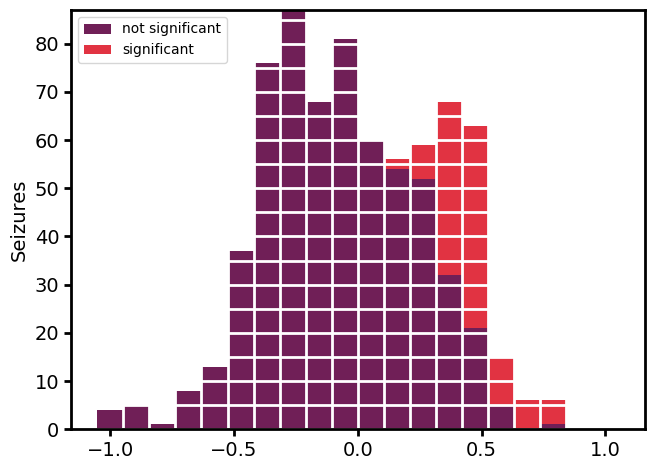

In [ ]:
plot_sig_nsig(all_spread_spike_ps.spread_r[all_spread_spike_ps.spread_p < 0.05],all_spread_spike_ps.spread_r[all_spread_spike_ps.spread_p >= 0.05],vbox_int=5)
plt.ylabel('Seizures')

In [ ]:
sc.stats.combine_pvalues(all_spread_spike_ps.spread_p.dropna())

SignificanceResult(statistic=2047.175877496083, pvalue=4.078402713017974e-25)

In [ ]:
all_spread_spike_ps.spread_r.mean()

0.045421995354903676

## EI and Seizure Spread

In [ ]:
ei_df = pd.read_csv(ospj(metapath,'EI_expanded_results_15052024.csv'))
ei_df['name'] = ei_df.name.str.strip('\'')
ei_df = ei_df[ei_df.EI != 'missing EI']
ei_df['EI'] = ei_df['EI'].astype(float)
ei_df = ei_df[ei_df.EI != 0]
ei_df.head()

/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_68329/3362016878.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  ei_df = pd.read_csv(ospj(metapath,'EI_expanded_results_15052024.csv'))


,hupID,rid,ictal_start_time,EI,name,removed_channels
0,HUP082,sub-RID0013,282387.0,0.077833,RG01,[]
1,HUP082,sub-RID0013,282387.0,0.050701,RG02,[]
2,HUP082,sub-RID0013,282387.0,0.051708,RG03,[]
3,HUP082,sub-RID0013,282387.0,0.048913,RG04,[]
4,HUP082,sub-RID0013,282387.0,0.046689,RG05,[]


In [ ]:
# Expand DataFrame
expanded_data = []
for _, row in summary_df_wmeta.iterrows():
    for ch,rank in row["channel_spread_rank"].items():
        expanded_data.append({
            "patient": row['patient'],
            "onset": row['onset'],
            "name": ch.split('-')[0],
            "sz_rank": rank,
            "outcome": row['outcome']
            # "time": row["channel_spread_time"][ch]
        })

# Create the expanded DataFrame
ei_long_df = pd.DataFrame(expanded_data)

In [ ]:
joint_ei_df = ei_long_df.merge(ei_df,left_on=['patient','onset','name'],right_on=['hupID','ictal_start_time','name'])

In [ ]:
all_rs = []
all_ps = []
all_out = []
for _,group in joint_ei_df.groupby(['patient','onset']):
    r,p = spearmanr(group.sz_rank,group.EI,alternative='less')
    all_rs.append(r)
    all_ps.append(p)
    all_out.append(group.outcome.iloc[0])
all_rs = np.array(all_rs)
all_ps = np.array(all_ps)
all_out = np.array(all_out)

/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_68329/1086767712.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,p = spearmanr(group.sz_rank,group.EI,alternative='less')


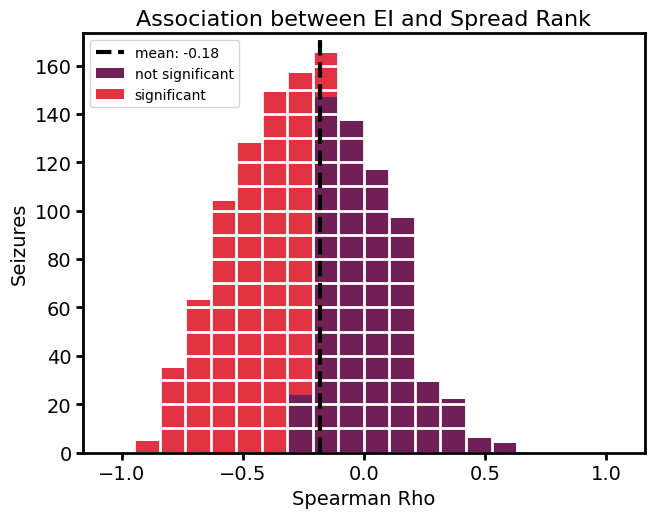

In [ ]:
_,ax=plot_sig_nsig(all_rs[all_ps < 0.05],all_rs[all_ps >= 0.05],vbox_int=10)
r_mean = np.mean(all_rs[~np.isnan(all_rs)])
ax.axvline(r_mean,linestyle='--',color='black',linewidth=3,label=f'mean: {r_mean:.2f}')
plt.xlabel('Spearman Rho')
plt.title('Association between EI and Spread Rank')
plt.ylabel('Seizures')
plt.legend()

## Seizure spread and resection

#### Data prep

In [281]:
resection_masks = pd.read_pickle(ospj(metapath,'resection_masks.pkl'))
resection_masks['resected'] = resection_masks['resected'] == 1

In [282]:
implanted_rois = resection_masks.groupby(['rid'])[['roiNum']].nunique().reset_index()
implanted_rois['rid'] = implanted_rois['rid'].astype(int)
implanted_rois['n_rois'] = implanted_rois.pop('roiNum')

resection_masks = resection_masks.merge(implanted_rois,on='rid',how='inner')

In [283]:
summary_df_wmetao = summary_df_wmeta[summary_df_wmeta['notes'].apply(lambda x: 'nina' not in x.lower()) & summary_df_wmeta['source'].apply(lambda x: 'nina' not in x.lower())]
resection_data = []
for _,row in summary_df_wmetao[(summary_df_wmetao.alt_focal == 'focal')].iterrows():
    for ch,time in row.channel_spread_time.items():
        resection_data.append({
            'rid': row['record_id'],
            'hup':row['patient'],
            'outcome': row['outcome'],
            "onset": row['onset'],
            # "alt_focal": row['alt_focal'],
            # 'all_focal': row['all_focal'],
            # "laterality": row['SOZ_lateralization'] == 'bilateral',
            'label': ch.split('-')[0],
            'latency': time,
            'rapid': time <= 15,
            'ndd1': np.array(row['onset_ndd_ind'][0])[np.array(row.all_channels) == ch][0],
            'ndd3': np.array(row['onset_ndd_ind'][1])[np.array(row.all_channels) == ch][0],
            'ndd5': np.array(row['onset_ndd_ind'][2])[np.array(row.all_channels) == ch][0],
            'ndd10': np.array(row['onset_ndd_ind'][3])[np.array(row.all_channels) == ch][0],
            'ndd15': np.array(row['onset_ndd_ind'][4])[np.array(row.all_channels) == ch][0],
            'num_ch': len(row.all_channels)
        })
resection_df_long = pd.DataFrame(resection_data)

In [284]:
resected_chs_wmask = pd.merge(resection_masks,resection_df_long,how='inner',on=['rid','label'])

In [285]:
resected_chs_wmask = resected_chs_wmask.dropna(subset=['roiNum','outcome'])

In [286]:
for pt,group in resected_chs_wmask.groupby('hup'):
    side = group.label.apply(lambda x: x[0])
    print(pt,group.rid.unique()[0],side.unique())

HUP073 63 ['L' 'R']
HUP074 64 ['A' 'F' 'G' 'H' 'L' 'M' 'P' 'T']
HUP087 20 ['L']
HUP093 50 ['A' 'D' 'P']
HUP094 51 ['L' 'R']
HUP097 33 ['A' 'D' 'I' 'L' 'M' 'P']
HUP099 32 ['A' 'D' 'M' 'O' 'P']
HUP105 101 ['L' 'R']
HUP106 143 ['L' 'R']
HUP107 117 ['L' 'R']
HUP111 179 ['L' 'R']
HUP116 175 ['R']
HUP130 238 ['L' 'R']
HUP135 274 ['R']
HUP138 278 ['L' 'R']
HUP141 294 ['R']
HUP142 295 ['L']
HUP145 167 ['R']
HUP162 412 ['L' 'R']
HUP165 325 ['L' 'R']
HUP170 442 ['L' 'R']
HUP171 371 ['L' 'R']
HUP172 440 ['L' 'R']
HUP179 139 ['L']
HUP184 508 ['L']
HUP189 520 ['L']
HUP191 454 ['L' 'R']
HUP194 562 ['R']
HUP201 595 ['L']
HUP206 572 ['R']
HUP208 648 ['L']
HUP215 566 ['L']
HUP216 658 ['L' 'R']
HUP218 677 ['R']
HUP219 695 ['R']
HUP223 785 ['L' 'R']


(0.6209385808146863, 178.0, 0.5493827160493827)


Text(0, 0.5, 'Percent Channels Resected')

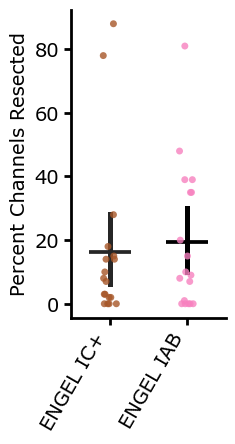

In [287]:
_,ax = plt.subplots(figsize=(2,4))
num_rs_df = resected_chs_wmask.groupby(['rid'])[['outcome','resected','num_ch']].agg(dict(outcome='mean',resected='sum',num_ch='mean')).reset_index()
# num_rs_df['resected'] = num_rs_df['resected']/num_rs_df['num_ch']
sns.stripplot(num_rs_df,
              x='outcome',
              y='resected',
              hue='outcome',
              palette=sns.color_palette('Set1')[6:8],
              legend=False,alpha=0.8)
sns.pointplot(num_rs_df,
              x='outcome',
              y='resected',
            #   order=[0,1],
            #   hue_order=[0,1],
              hue='outcome',
              estimator='mean',
              markers='_',
              markersize=30,
            #   palette='rocket',
              palette='dark:black',
              legend=False)
plt.xticks([0,1],['ENGEL IC+','ENGEL IAB'],rotation=60,ha='right')
print(get_nparam_stats(num_rs_df,'outcome',1,0,'resected'))
sns.despine()
plt.xlabel('')
plt.ylabel('Percent Channels Resected')

In [288]:
pt_resected_chs_wmask = resected_chs_wmask.groupby(['rid','label'])[['outcome','latency','rapid','ndd1','ndd3','ndd5','ndd10','resected','num_ch','roiNum','n_rois']].mean().reset_index()
pt_resected_chs_wmask['Tissue'] = pt_resected_chs_wmask['resected'].apply(lambda x: ['Spared','Resected'][int(x)])

In [289]:
pt_resected_chs_wmask.rid.nunique()

36

In [290]:
resected_rs_wmask = resected_chs_wmask.groupby(['rid','onset','roiNum']).aggregate({'outcome':'max',
                                                                                    # 'latency':lambda x: np.percentile(x,25),
                                                                                    'latency':'min',
                                                                                    'resected': 'mean','rapid':'max','num_ch':'mean','n_rois':'mean',
                                                                                    'num_ch':'mean'}).reset_index()
resected_rs_wmask['resected'] = resected_rs_wmask['resected']>0
# resected_rs_wmask = resected_chs_wmask 
resected_rs_wmask['Tissue'] = resected_rs_wmask['resected'].apply(lambda x: ['Spared','Resected'][int(x)])


In [291]:
resected_rs_wmask.onset.nunique()

265

#### Plotting interlude

In [292]:
all_rs_img = nib.load('/Applications/freesurfer/7.4.1/subjects/cvs_avg35_inMNI152/mri/aparc+aseg.mgz')
og_affine = all_rs_img.affine
all_rs_mask = all_rs_img.get_fdata()
plot_subset = resected_rs_wmask[resected_rs_wmask.rid==51] # 51
resected_rs = plot_subset[plot_subset.resected].roiNum.unique()
spared_rs = plot_subset[~plot_subset.resected].roiNum.unique()
resected_rs_mask = np.isin(all_rs_mask,resected_rs)
resected_rs_img = nib.Nifti1Image(resected_rs_mask.astype(float),og_affine)
nib.save(resected_rs_img,ospj(prodatapath,'resected_rs.mgz'))
spared_rs_mask = np.isin(all_rs_mask,spared_rs)
spared_rs_img = nib.Nifti1Image(spared_rs_mask.astype(float),og_affine)
nib.save(spared_rs_img,ospj(prodatapath,'spared_rs.mgz'))
null_rs_mask = all_rs_mask.copy()
null_rs_mask[spared_rs_mask]=False
null_rs_mask[resected_rs_mask]=False
null_rs_img = nib.Nifti1Image(null_rs_mask.astype(float),og_affine)
nib.save(null_rs_img,ospj(prodatapath,'null_rs.mgz'))

print(resected_rs)

[  53.   54. 2009. 2033.]


In [293]:
plot_electrodes = resected_chs_wmask[(resected_chs_wmask.onset==445516.0)].sort_values('label').reset_index(drop=True) ## VISUALIZATION
# plot_electrodes = resected_chs_wmask[(resected_chs_wmask.onset== 178818.12)].sort_values('label').reset_index(drop=True)
plot_electrodes['Radius']=3
plot_electrodes['Label'] = plot_electrodes['label']
plot_electrodes[['MNI152_x','MNI152_y','MNI152_z']] = nib.affines.apply_affine(og_affine,plot_electrodes[['vox_x','vox_y','vox_z']].to_numpy())
plot_electrodes[['T1R','T1A','T1S']] = plot_electrodes[['mm_x','mm_y','mm_z']]
plot_electrodes.reset_index(names='Electrode',inplace=True)
plot_electrodes['Electrode'] += 1
plot_cols = ['Electrode','MNI152_x','MNI152_y','MNI152_z','T1R','T1A','T1S','Label','Radius','latency']
plot_table = plot_electrodes[plot_cols]
plot_table.to_csv(ospj(metapath,'rave_electrodes.csv'),index=False)

In [294]:
seizure_data = pd.read_pickle(ospj(prodatapath,'HUP094','seizure-445516.0_fs-256_prebuff-120_postbuff120.pkl'))
# seizure_data = pd.read_pickle(ospj(prodatapath,'HUP208','seizure-178818.12_fs-256_prebuff-120_postbuff120.pkl'))
onset_idx = 220
offset_idx = len(seizure_data)-240
seizure_data.columns = [x.split('-')[0] for x in seizure_data.columns]
seizure_crop  = seizure_data.iloc[onset_idx:offset_idx,:]
seizure_crop.loc[:,['Time']] = np.arange(0,len(seizure_crop))*0.5
seizure_long = seizure_crop.melt(id_vars='Time',value_name='NDD',var_name='Label')
rave_seizure = pd.merge(plot_table[['Electrode','Label']],seizure_long,on='Label')
rave_seizure.drop('Label',axis=1).to_csv(ospj(metapath,'rave_seizure.csv'),index=False)

#### Resume outcomes

(0.6570226943052402, 176.5, 0.5447530864197531)


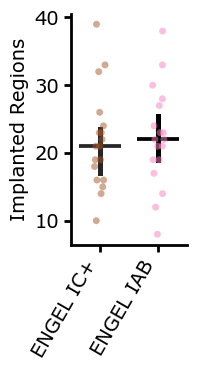

In [295]:
_,ax = plt.subplots(figsize=(1.5,3))
num_rs_df = resected_rs_wmask.groupby(['rid'])[['n_rois','outcome','num_ch']].mean().reset_index()
sns.stripplot(num_rs_df,
              x='outcome',
              y='n_rois',
              hue='outcome',
              palette=sns.color_palette('Set1')[6:8],
              legend=False,
              alpha=0.5)
sns.pointplot(num_rs_df,
              x='outcome',
              y='n_rois',
              hue='outcome',
              estimator='median',
              markers='_',
              markersize=30,
            #   palette='rocket',
              palette='dark:black',
              legend=False)
plt.xticks([0,1],['ENGEL IC+','ENGEL IAB'],rotation=60,ha='right')
print(get_nparam_stats(num_rs_df,'outcome',1,0,'n_rois'))
sns.despine()
plt.xlabel('')
plt.ylabel('Implanted Regions')
plt.savefig(ospj(figpath,'outcome_regions.pdf'),bbox_inches='tight')

#### Analyses

##### Has Sz spread outside resection mask? (r)

In [296]:
resected=False
all_ds=[]
all_ps = []
all_us = []
ts = range(1,61,1)
line_plotting_list = []
box_plotting_list = []

for t in ts:
    resected_rs_wmask['rapid'] = resected_rs_wmask['latency'] < t
    resected_rs_wmask['seizing'] = resected_rs_wmask['rapid']
    plot_df = resected_rs_wmask.groupby(['rid','onset','Tissue'])[['seizing','outcome','resected']].aggregate({"seizing": "sum", "outcome": 'mean','resected':'mean'}).reset_index()
    plot_df['time'] = [t]*len(plot_df)
    plot_df['Outcome'] = plot_df['outcome'].apply(lambda x: np.array(['ENGEL IC+','ENGEL IAB'])[int(x)])
    line_plotting_list.append(plot_df)
    box_plotting_list.append(plot_df)
    d_list = []
    p_list = []
    u_list = []
    for i,r in enumerate([True,False]):
        d_list.append(cohens_d(plot_df[(plot_df.outcome==0) & (plot_df.resected == r)].seizing,
                plot_df[(plot_df.outcome==1) & (plot_df.resected == r)].seizing))
        u,p = sc.stats.mannwhitneyu(plot_df[(plot_df.outcome==0) & (plot_df.resected == r)].seizing,
                                    plot_df[(plot_df.outcome==1) & (plot_df.resected == r)].seizing,
                                    alternative='greater'
                                    )
        p_list.append(p)
        u_list.append(u/(len(plot_df[(plot_df.outcome==0) & (plot_df.resected == r)])*len(plot_df[(plot_df.outcome==1) & (plot_df.resected == r)])))

    all_df = resected_rs_wmask.groupby(['rid','onset'])[['seizing','outcome']].aggregate({"seizing": "sum", "outcome": 'mean'}).reset_index()
    all_df['Tissue'] = 'All'
    all_df['time'] = [t]*len(all_df)
    all_df['Outcome'] = all_df['outcome'].apply(lambda x: np.array(['ENGEL IC+','ENGEL IAB'])[int(x)])
    box_plotting_list.append(all_df)
    d_list.append(cohens_d(all_df[all_df.outcome==0].seizing,
                all_df[all_df.outcome==1].seizing))
    u,p = sc.stats.mannwhitneyu(all_df[(all_df.outcome==0)].seizing,
                                    all_df[all_df.outcome==1].seizing,
                                    alternative='greater'
                                    )
    p_list.append(p)
    u_list.append(u/(len(all_df[(all_df.outcome==0)])*len(all_df[(all_df.outcome==1)])))
    
    all_ds.append(d_list)
    all_ps.append(p_list)
    all_us.append(u_list)
all_ds = np.abs(np.array(all_ds))
all_ps = np.abs(np.array(all_ps))
all_us = np.abs(np.array(all_us))

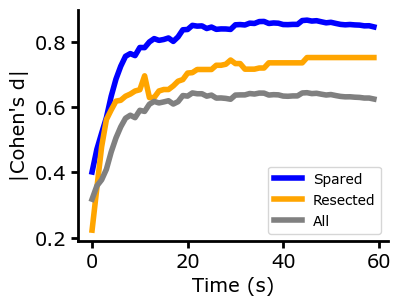

In [297]:
_,ax = plt.subplots(figsize=(4,3))
# ax.axvline(20,linewidth=2,linestyle='--',c='black')
all_us = np.abs(all_us-.5)
plt.plot(all_ds[:,1],c='blue',linewidth=4,label='Spared')
plt.plot(np.abs(all_ds[:,0]),c='orange',linewidth=4,label='Resected')
plt.plot(all_ds[:,2],c='grey',linewidth=4,label='All')
plt.legend()
plt.ylabel('|Cohen\'s d|')
plt.xlabel('Time (s)')
sns.despine()
plt.savefig(ospj(figpath,'cohend_outcome_resection.pdf'),bbox_inches='tight')

In [259]:
def find_knee(x, y):
    # First and last points
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])

    # Line vector and normalize
    line_vec = p2 - p1
    line_vec_norm = line_vec / np.linalg.norm(line_vec)

    # Compute distances from the line
    vec_from_p1 = np.array([x, y]).T - p1
    projection = np.dot(vec_from_p1, line_vec_norm)
    proj_vec = np.outer(projection, line_vec_norm)
    dist_vec = vec_from_p1 - proj_vec
    distances = np.linalg.norm(dist_vec, axis=1)

    # Knee point
    knee_idx = np.argmax(distances)

    return knee_idx
find_knee(range(1,61,1),all_ds[:,1])

8

9
37
0.8312762460432064
3


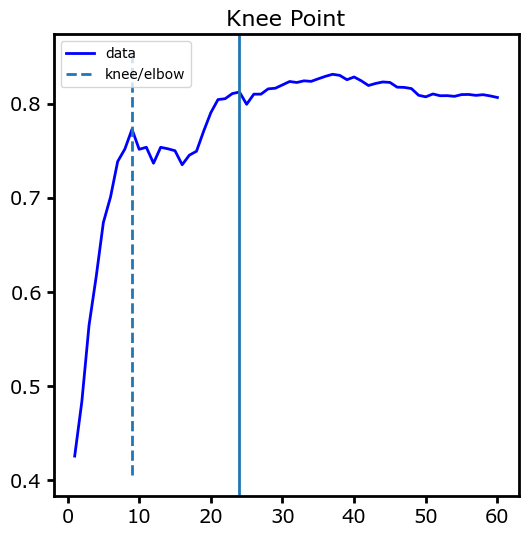

In [260]:
kl = KneeLocator(range(1,61,1),all_ds[:,1],curve='concave')
kl.plot_knee()
print(kl.knee)
print(np.argmax(all_ds[:,1])+1)
print(all_ds[np.argmax(all_ds[:,1]),1])
print(np.argwhere(all_ds[:,1]>0.6)[0][0])
plt.axvline(24)

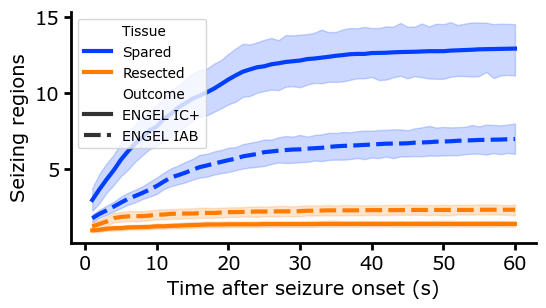

In [261]:
_,ax = plt.subplots(figsize=(6,3))
line_plotting_df = pd.concat(line_plotting_list)
sns.lineplot(line_plotting_df,x='time',y='seizing',
             hue='Tissue',
             palette = 'bright',
             style='Outcome',
             hue_order=['Spared','Resected'],
            #  style_order=['Spared','Resected'],
             linewidth=3)

plt.ylabel('Seizing regions')
plt.xlabel('Time after seizure onset (s)')
sns.despine()
plt.savefig(ospj(figpath,'seizure_spread_outcome_resection.pdf'),bbox_inches='tight')
# leg = plt.legend()
# [t.set_color(c) for t,c in zip(leg.get_texts()[-2:],['blue','orange'])]
plt.show()

max_d_idx = np.where(all_ps < 0.05)[0][0]
max_t = ts[max_d_idx] - 1

# # plt.axvline(max_t,c='black',linestyle='--')
# plt.text(max_t-1,all_ds[max_t],'*',fontdict={'weight':'bold','size':18})
# plt.text(max_t+5,all_ds[max_t],f'p = {all_ps[max_d_idx]: .4f}',{'weight':'bold','size':12,'style':'italic'})
# plt.xlabel('Time since seizure onset (s)')
# plt.ylabel('Cohen\'s d')
# plt.title('Difference in extra-resection spread by outcome')
# sns.despine()
# plt.show()
# print(max_t)

[None, None]

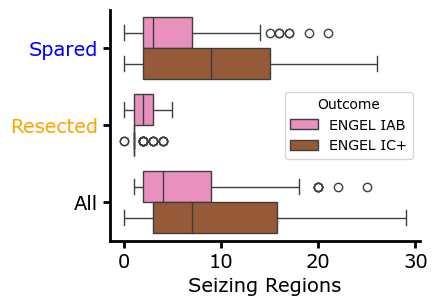

In [262]:
box_plotting_df = pd.concat(box_plotting_list)
_,ax = plt.subplots(figsize=(4,3))

sns.boxplot(box_plotting_df[box_plotting_df.time == 15],
               y='Tissue',x='seizing',
               order=['Spared','Resected','All'],
               hue='Outcome',
               palette=sns.color_palette('Set1')[6:8][::-1],
               dodge=True,
               hue_order=['ENGEL IAB','ENGEL IC+'],
               ax=ax,
               orient='h',
            #    split=True,
            #    inner=None,
            #    gap=.03,
            #    fill=False,
               )
               
plt.xlabel('Seizing Regions')
plt.ylabel('')
sns.despine()
[t.set_color(i) for (i,t) in
zip(['blue','orange'],ax.yaxis.get_ticklabels())]

##### Has the seizure spread outside the resection mask? (percent)

In [ ]:
resected=False
all_ds=[]
all_ps = []
all_us = []
ts = range(1,101,1)
line_plotting_list = []
box_plotting_list = []

for t in ts:
    resected_rs_wmask['rapid'] = resected_rs_wmask['latency'] < t
    resected_rs_wmask['seizing'] = resected_rs_wmask['rapid']/resected_rs_wmask['n_rois']*100
    plot_df = resected_rs_wmask.groupby(['rid','onset','Tissue'])[['seizing','outcome','resected']].aggregate({"seizing": "sum", "outcome": 'mean','resected':'mean'}).reset_index()
    plot_df['time'] = [t]*len(plot_df)
    plot_df['Outcome'] = plot_df['outcome'].apply(lambda x: np.array(['ENGEL IC+','ENGEL IAB'])[int(x)])
    line_plotting_list.append(plot_df)
    box_plotting_list.append(plot_df)
    d_list = []
    p_list = []
    u_list = []
    for i,r in enumerate([True,False]):
        d_list.append(cohens_d(plot_df[(plot_df.outcome==0) & (plot_df.resected == r)].seizing,
                plot_df[(plot_df.outcome==1) & (plot_df.resected == r)].seizing))
        u,p = sc.stats.mannwhitneyu(plot_df[(plot_df.outcome==0) & (plot_df.resected == r)].seizing,
                                    plot_df[(plot_df.outcome==1) & (plot_df.resected == r)].seizing,
                                    alternative='greater'
                                    )
        p_list.append(p)
        u_list.append(u/(len(plot_df[(plot_df.outcome==0) & (plot_df.resected == r)])*len(plot_df[(plot_df.outcome==1) & (plot_df.resected == r)])))

    all_df = resected_rs_wmask.groupby(['rid','onset'])[['seizing','outcome']].aggregate({"seizing": "sum", "outcome": 'mean'}).reset_index()
    all_df['Tissue'] = 'All'
    all_df['time'] = [t]*len(all_df)
    all_df['Outcome'] = all_df['outcome'].apply(lambda x: np.array(['ENGEL IC+','ENGEL IAB'])[int(x)])
    box_plotting_list.append(all_df)
    d_list.append(cohens_d(all_df[all_df.outcome==0].seizing,
                all_df[all_df.outcome==1].seizing))
    u,p = sc.stats.mannwhitneyu(all_df[(all_df.outcome==0)].seizing,
                                    all_df[all_df.outcome==1].seizing,
                                    alternative='greater'
                                    )
    p_list.append(p)
    u_list.append(u/(len(all_df[(all_df.outcome==0)])*len(all_df[(all_df.outcome==1)])))
    
    all_ds.append(d_list)
    all_ps.append(p_list)
    all_us.append(u_list)

all_ds = np.array(all_ds)
all_ps = np.array(all_ps)
all_us = np.array(all_us)

In [ ]:
# resected = False
# all_ds = []
# all_ps = []
# ts = range(1,101,1)
# line_plotting_list = []
# for t in ts:
#     resected_rs_wmask['rapid'] = resected_rs_wmask['latency'] < t
#     resected_rs_wmask['outside_resection'] = resected_rs_wmask['rapid']/resected_rs_wmask['n_rois']*100
#     plot_df = resected_rs_wmask.groupby(['rid','onset','resected'])[['outside_resection','outcome']].aggregate({"outside_resection": "sum", "outcome": 'mean'}).reset_index()
#     plot_df['time'] = [t]*len(plot_df)
#     plot_df['Outcome'] = plot_df['outcome'].apply(lambda x: np.array(['ENGEL IC+','ENGEL IAB'])[int(x)])
#     line_plotting_list.append(plot_df)
#     _,p = sc.stats.mannwhitneyu(plot_df[(plot_df.outcome==0) & (plot_df.resected == resected)].outside_resection,
#                                     plot_df[plot_df.outcome==1 & (plot_df.resected == resected)].outside_resection,
#                                     alternative='greater')
    
#     d_list = []
#     for i,r in enumerate([True,False]):
#         d_list.append(cohens_d(plot_df[plot_df.outcome==0 & (plot_df.resected == r)].outside_resection,
#                 plot_df[plot_df.outcome==1 & (plot_df.resected == r)].outside_resection))
#     all_ds.append(d_list)
#     all_ps.append(p)
    
# all_ds = np.array(all_ds)

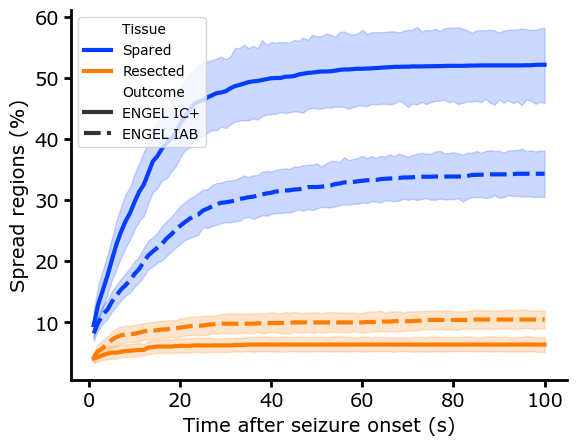

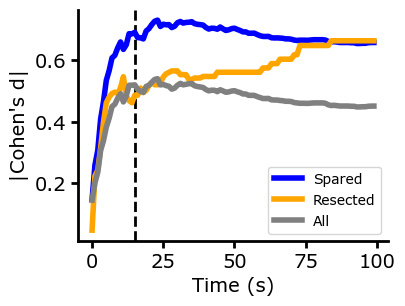

In [ ]:
line_plotting_df = pd.concat(line_plotting_list)
sns.lineplot(line_plotting_df,x='time',y='seizing',hue='Tissue',
             palette = 'bright',
             style='Outcome',linewidth=3,
             hue_order=['Spared','Resected'])
plt.ylabel('Spread regions (%)')
plt.xlabel('Time after seizure onset (s)')
sns.despine()
plt.show()

_,ax = plt.subplots(figsize=(4,3))
ax.axvline(15,linewidth=2,linestyle='--',c='black')

plt.plot(all_ds[:,1],c='blue',linewidth=4,label='Spared')
plt.plot(np.abs(all_ds[:,0]),c='orange',linewidth=4,label='Resected')
plt.plot(all_ds[:,2],c='grey',linewidth=4,label='All')
plt.legend()
plt.ylabel('|Cohen\'s d|')
plt.xlabel('Time (s)')
sns.despine()

<Axes: xlabel='resected', ylabel='outside_resection'>

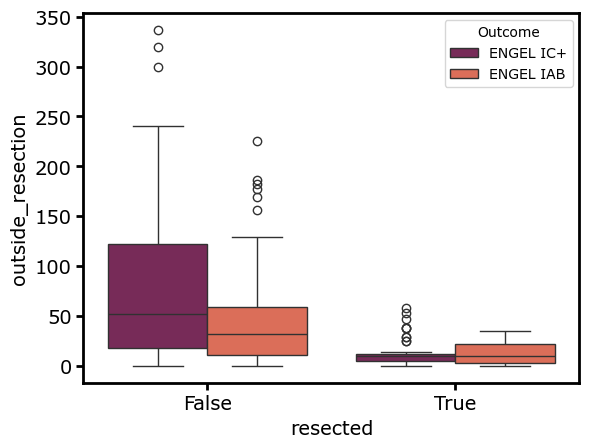

In [ ]:
sns.boxplot(line_plotting_df[line_plotting_df.time == 10],x='resected',y='outside_resection',hue='Outcome',palette='rocket')

##### Has sz spread outside resection mask? (pt)

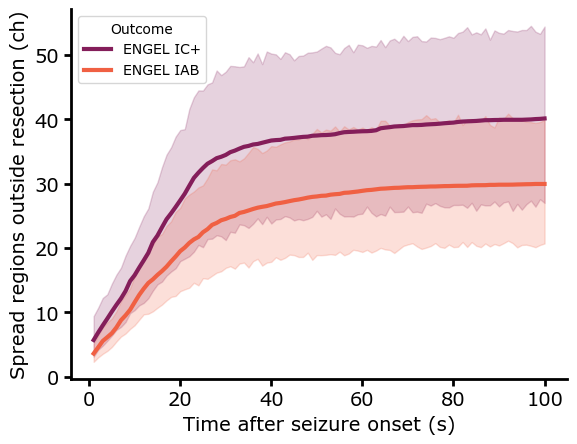

In [ ]:
all_ds = []
all_ps = []
ts = range(1,101,1)
line_plotting_list = []
for t in ts:
    resected_rs_wmask['rapid'] = resected_rs_wmask['latency'] < t
    resected_rs_wmask['outside_resection'] = resected_rs_wmask['rapid']#/resected_rs_wmask['num_rs']*100
    plot_df = resected_rs_wmask[resected_rs_wmask.resected == False].groupby(['rid','onset'])[['outside_resection','outcome']].aggregate({"outside_resection": "sum", "outcome": 'mean'}).reset_index()
    pt_plot_df = plot_df.groupby('rid')[['outside_resection','outcome']].aggregate({"outside_resection": "mean", "outcome": 'mean'}).reset_index()
    pt_plot_df['time'] = [t]*len(pt_plot_df)
    pt_plot_df['Outcome'] = pt_plot_df['outcome'].apply(lambda x: np.array(['ENGEL IC+','ENGEL IAB'])[int(x)])
    line_plotting_list.append(pt_plot_df)
    _,p = sc.stats.mannwhitneyu(pt_plot_df[pt_plot_df.outcome==0].outside_resection,
                                    pt_plot_df[pt_plot_df.outcome==1].outside_resection)
    d = cohens_d(pt_plot_df[pt_plot_df.outcome==0].outside_resection,
                                pt_plot_df[pt_plot_df.outcome==1].outside_resection)
    all_ds.append(d)
    all_ps.append(p)
line_plotting_df = pd.concat(line_plotting_list)
sns.lineplot(line_plotting_df,x='time',y='outside_resection',hue='Outcome',palette = 'rocket',linewidth=3)
plt.ylabel('Spread regions outside resection (ch)')
plt.xlabel('Time after seizure onset (s)')
sns.despine()
plt.show()
# plt.plot(all_ds,c=sns.color_palette('rocket_r')[3],linewidth=4)
# max_d_idx = np.where(np.array(all_ps) < 0.05)[0][0]
# max_t = ts[max_d_idx]
# plt.axvline(max_t,c='black',linestyle='--')
# plt.text(max_t+5,all_ds[max_t],f'p = {all_ps[max_d_idx]: .4f}',{'weight':'bold','size':12,'style':'italic'})
# plt.xlabel('Time since seizure onset (s)')
# plt.ylabel('Cohen\'s d')
# plt.title('Difference in extra-resection spread by outcome')
# sns.despine()
# plt.show()
# print(max_t)

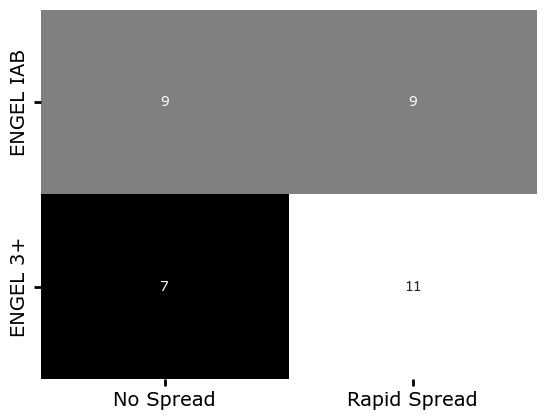

In [ ]:
# Load the dataset
data = line_plotting_df

# Initialize results dictionary
results = []

# Iterate through each time point
time_points = data['time'].unique()
for time in time_points:
    for n in [10]:#range(1,16):
        
        subset = data[data['time'] == time]
        
        true_labels = subset['outcome'] == 0
        predictions = subset['outside_resection'] > n

        # Calculate confusion matrix
        tn, fp, fn, tp = confusion_matrix(true_labels, predictions).ravel()
        
        # Calculate sensitivity and specificity
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp/(tp+fp) if (tp+fp) > 0 else 0
        npv = tn/(tn+fn) if (tn+fn) > 0 else 0
        # Calculate AUC
        auc = roc_auc_score(true_labels, subset['outside_resection'])
        
        results.append({'time': time, 'sensitivity': sensitivity, 'specificity': specificity, 'ppv':ppv,'npv':npv,'nregions': n})#, 'auc': auc})
        if time  == 10:
            sns.heatmap([[tn,fp],[fn,tp]],annot=True,cbar=False,cmap='gray')
            plt.yticks([0.5,1.5],['ENGEL IAB','ENGEL 3+',])
            plt.xticks([0.5,1.5], ['No Spread','Rapid Spread',])
            plt.show()

# Convert results to DataFrame
results_df = pd.DataFrame(results)
results_long = results_df.melt(id_vars=['time','nregions'], var_name='metric', value_name='value')

(0.0, 20.0)

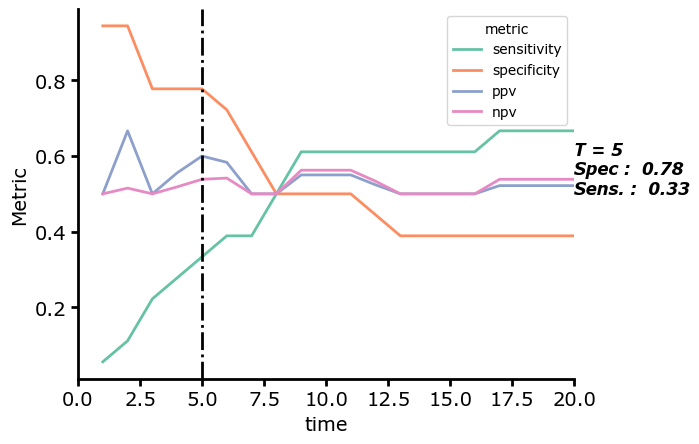

In [ ]:
# sns.lineplot(results_long[results_long['metric'] == 'specificity'],x='time',y='value',hue='nregions',palette='rocket')
# sns.lineplot(results_long[results_long['metric'] == 'sensitivity'],x='time',y='value',hue='nregions',palette='viridis')
sns.lineplot(results_long,x='time',y='value',hue='metric',palette='Set2')
T = 5
plt.axvline(T,c='black',linestyle='-.')
plt.text(20,.5,
         f'T = {T}\nSpec : {results_long.value[(results_long.metric == "specificity") & (results_long.time == T)].item() : .2f} \nSens. : {results_long.value[(results_long.metric == "sensitivity") & (results_long.time == T)].item() : .2f}',
         {'weight':'bold','size':12,'style':'italic'})
sns.despine()
plt.ylabel('Metric')
plt.xlim([0,20])

##### Proportion of rapid spread channels outside the resection mask

In [ ]:
pt_resected_rs_wmask.groupby(['outcome','resected'])['rapid'].mean().reset_index()

,outcome,resected,rapid
0,0.0,False,0.641566
1,0.0,True,0.942857
2,1.0,False,0.626703
3,1.0,True,0.900000


0.9689546308508231


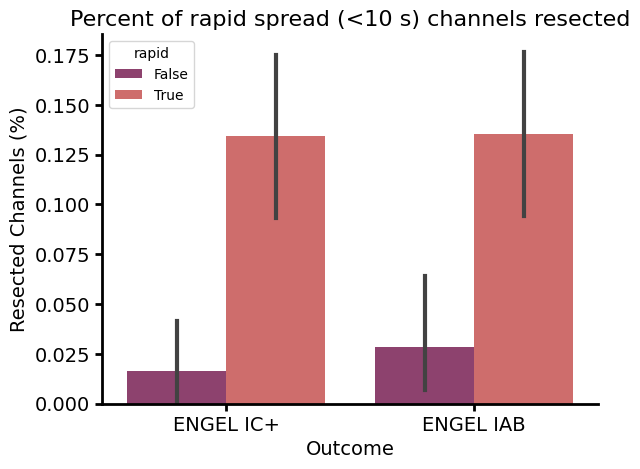

In [ ]:
plot_df = pt_resected_rs_wmask
sns.barplot(plot_df,x='outcome',y='resected',hue='rapid',palette='flare_r')
plt.ylabel('Resected Channels (%)')
plt.xlabel('Outcome')
plt.xticks([0,1],['ENGEL IC+','ENGEL IAB'])
stats_mask1 = (plot_df['outcome'] == 0) & (plot_df['rapid'])
stats_mask2 = (plot_df['outcome'] == 1) & (plot_df['rapid'])
_,p = sc.stats.mannwhitneyu(plot_df[stats_mask1].resected,plot_df[stats_mask2].resected)
plt.title(f"Percent of rapid spread (<10 s) channels resected")
print(p)
sns.despine()

0.006721491632002895
-0.20192579578865347


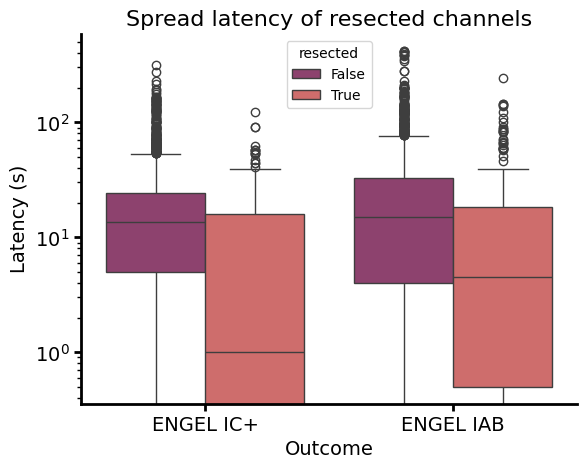

In [ ]:
plot_df = resected_rs_wmask
sns.boxplot(plot_df,x='outcome',y='latency',hue='resected',palette='flare_r')
plt.ylabel('Latency (s)')
plt.xlabel('Outcome')
plt.xticks([0,1],['ENGEL IC+','ENGEL IAB'])
# stats_mask1 = (plot_df['outcome'] == 0) & (~plot_df['resected'])
# stats_mask2 = (plot_df['outcome'] == 1) & (~plot_df['resected'])
stats_mask1 = (plot_df['outcome'] == 0)
stats_mask2 = (plot_df['outcome'] == 1)
_,p = sc.stats.mannwhitneyu(plot_df[stats_mask1].latency,plot_df[stats_mask2].latency)
d = cohens_d(plot_df[stats_mask1].latency,plot_df[stats_mask2].latency)
plt.title(f"Spread latency of resected channels")
print(p)
print(d)
plt.yscale('log')
sns.despine()

<Axes: xlabel='outcome', ylabel='resected'>

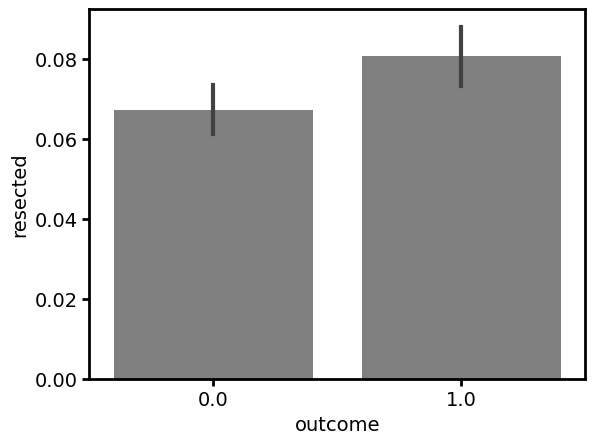

In [ ]:
sns.barplot(resected_chs_wmask,y='resected',x='outcome',color='grey')